In [64]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 100)

setwd('/sc/arion/projects/roussp01a/liting/Olf')

library(rlang)
library(RColorBrewer)
library(scales)
library(tradeSeq)
library(schard)
library(SeuratWrappers)
library(ggVennDiagram)
library(stringr)
library(rrvgo)
library(slingshot)
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(gprofiler2)
library(monocle3)
library(ggplot2)

In [65]:
#sessionInfo()

In [66]:
# functions 
scanpy2seurat <- function(file_name){
  h5ad=paste0('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/',file_name,'.h5ad')
  rds=paste0('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/',file_name,'.rds')
  ent = schard::h5ad2seurat(h5ad)
  saveRDS(ent,rds)
}

read_obj <- function(file_name, hvg){
  ent_N <- readRDS(paste0('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/',file_name,'.rds'))
  names(ent_N@reductions) <- gsub('^X|_$','',names(ent_N@reductions))
  ent_N <- FindVariableFeatures(ent_N,nfeatures = hvg) # for identify DEGs using slingshot
  return(ent_N)
}

#N_color <- c('#1f77b4','#ff7f0e',"#D32B29")
N_color <- c( '#1f77b4','#FDBF6F','#ff7f0e',"#D32B29")
names(N_color) <- c('GBC','e_iOSN','l_iOSN','mOSN' )



get_slingshot_traj <- function(obj){
  dimred <- obj@reductions$umap.cca@cell.embeddings
  #clustering <- as.numeric(obj$N_leiden_res0_25)+1
  clustering <- obj$cca_N_types_stage
  
  set.seed(1)
  pto <- slingshot(dimred, clustering, start.clus = 'GBC')
  obj$sling_pseudotime <-  slingPseudotime(pto)
  FeaturePlot(object = obj, features = 'sling_pseudotime',reduction = "umap.cca")
  
  png(filename = "./figures/NC/outermerge_slingshot_pseudotime.png",width = 8, height = 8, units = "cm", res=300)
  
  plot(dimred[, 1:2], col = N_color[clustering], cex = 0.5, pch = 16)
  lines(SlingshotDataSet(pto), lwd=2, col='black')
  dev.off()
  return(obj)
}

tradeseq_DEG <- function(data_ns, traj_method){
  
  data_ns$cca_clusters <- obj$cca_clusters
  counts <- as.matrix(data_ns@assays$RNA@counts)#as.matrix(data_ns@assays$RNA@counts[data_ns@assays$RNA@var.features, ])
  filt_counts <- counts#[rowSums(counts > 0) > ncol(counts)/100, ]
  Pseudotime <- as.matrix(data_ns$sling_pseudotime) 
  
  #batch <- data_ns$dataset
  #U <- model.matrix(~batch)
  U <- model.matrix(~ dataset  + Sex + Age +log(nCount_RNA), data = data_ns@meta.data)
  
  sce <- fitGAM(counts = as.matrix(filt_counts),
                pseudotime = Pseudotime,U=U,
                cellWeights = as.matrix(rep(1,ncol(data_ns))))
  
  # test for dynamic expression
  pseudotime_association <- associationTest(sce)
  
  pseudotime_association$fdr <- p.adjust(pseudotime_association$pvalue, method = "fdr")
  pseudotime_association <- pseudotime_association[order(pseudotime_association$pvalue), ]
  pseudotime_association$feature_id <- rownames(pseudotime_association)
  pseudotime_association_sig <- subset(pseudotime_association, fdr < 0.05)
  
  return(pseudotime_association_sig)
  #return(pseudotime_association)
}



get_monocle3_traj <- function(scdata,lab,mm, res_traj,ncent){
  # input: scanpy data
  # get root node from plot_cells
  
  # as Monocle3 data
  mnc3_data <- SeuratWrappers::as.cell_data_set(scdata)
  mnc3_data <- estimate_size_factors(mnc3_data)
  
  # Cluster your cells
  mnc3_data <- cluster_cells(mnc3_data,resolution=res_traj, k =100)
  mnc3_data <- learn_graph(mnc3_data, use_partition = F, 
                           learn_graph_control = list(
    #minimal_branch_len = 100,
    ncenter = ncent#,
  #  geodesic_distance_ratio = 0.5
                           )
                          ) #   # Learn the trajectory graph
  plot_cells(mnc3_data, color_cells_by = "cca_N_types_stage",  cell_size = 1, label_principal_points = F, label_leaves=F,
           label_branch_points=F)
  
  print('-------------check root cell based on umap--------------------')
  if(lab=='x' & mm=='max'){rootcell = names(which.max(subset(data_ns, cca_N_types =='GBC')@reductions$umap@cell.embeddings[,1])) }
  if(lab=='x' & mm=='min'){rootcell = names(which.min(subset(data_ns, cca_N_types =='GBC')@reductions$umap@cell.embeddings[,1])) }
  if(lab=='y' & mm=='max'){rootcell = names(which.max(subset(data_ns, cca_N_types =='GBC')@reductions$umap@cell.embeddings[,2])) }
  if(lab=='y' & mm=='min'){rootcell = names(which.min(subset(data_ns, cca_N_types =='GBC')@reductions$umap@cell.embeddings[,2])) }

  mnc3_data <- order_cells(mnc3_data, root_cells= rootcell )
  plot_cells(mnc3_data, color_cells_by = "pseudotime",  cell_size = 1)
  
  return(mnc3_data)
}

get_monocle3_DEG <- function(mnc3_data){
  
  pr_test_res <- monocle3:::graph_test(mnc3_data, neighbor_graph="principal_graph", cores=6)
    
  pr_test_res <- pr_test_res[order(pr_test_res$q_value),]
  pr_test_res_sig <- subset(pr_test_res ) # get_monocle3_DEG #& morans_I > 0.1  & morans_I > 0.05
  return(pr_test_res_sig)
  #return(pr_test_res)
}

get_monocle3_DEG_contBatch <- function(mnc3_data){
  mnc3_data$Age <- scale(mnc3_data$Age)
  pr_test_res <- fit_models(mnc3_data,model_formula_str = "~monocle3_pseudotime + dataset ")#expression_family="negbinomial", + Sex + Age
  pr_test_res <- coefficient_table(pr_test_res)
  pr_test_res <- pr_test_res %>% filter(term == "monocle3_pseudotime") %>%
    select(gene_id, term, q_value, estimate)
  pr_test_res <- pr_test_res[order(pr_test_res$q_value),]
  pr_test_res_sig <- subset(pr_test_res, q_value < 0.05 )
  pr_test_res_sig <- as.data.frame(pr_test_res_sig)
  rownames(pr_test_res_sig) <- pr_test_res_sig$gene_id
  

  return(pr_test_res_sig)
  #return(pr_test_res)
}


get_heatmap_re_cluster_kmeans <- function(scdata, method, DEGs, n_split, recluster_id,n_REsplit){
  
  #if (method=='monocle') { pseudoTime <- pseudotime(scdata) }
  if (method=='monocle3') { pseudoTime <- scdata$monocle3_pseudotime}
  if (method=='slingshot') { pseudoTime <- scdata$sling_pseudotime }
  if (method=='palantir') { pseudoTime = scdata$palantir_pseudotime}
  if (method=='paga') { pseudoTime = scdata$dpt_pseudotime}  
  
  pt.matrix1 <- as.matrix(scdata@assays$RNA@counts[rownames(DEGs),order(pseudoTime)])
  #pt.matrix1 <- as.matrix(scdata[["RNA"]]$data[rownames(DEGs),order(pseudoTime)])
  #pt.matrix1 <- as.matrix(scdata[["RNA"]]$scale.data[rownames(DEGs),order(pseudoTime)])
  
  #Can also use "normalized_counts" instead of "exprs" to use various normalization methods, for example:
  #normalized_counts(cds, norm_method = "log")
  pt.matrix <- pt.matrix1
  pt.matrix <- t(apply(pt.matrix,1,function(x){smooth.spline(x,df=3)$y}))
  pt.matrix <- t(apply(pt.matrix,1,function(x){(x-mean(x))/sd(x)}))
  
  pt.matrix[pt.matrix > 4] = 4
  pt.matrix[pt.matrix < -4] = -4
  # 
  
  rownames(pt.matrix) <- rownames(DEGs);
  colnames(pt.matrix) <- colnames(scdata)[order(pseudoTime)]
  
  set.seed(42)
  
  ks_1st <- kmeans(pt.matrix, centers = n_split , iter.max = 100)
  C_K1 <- ks_1st$cluster
  C_K2 <- ''
  if (recluster_id!=''){
    ks_2st <- kmeans(pt.matrix[ks_1st$cluster==recluster_id,], centers = n_REsplit, iter.max = 100)
    C_K2 <- ks_2st$cluster[names(ks_1st$cluster)]
    C_K2 <- ifelse(is.na(C_K2),'',paste0('-',C_K2))
    
  }
  

    rowsplit <- paste0(C_K1,C_K2)
    dict_cluster <- c('iOSN','GBC','mOSN')
    names(dict_cluster) <- names(sort(table(rowsplit)))
    rowsplit=dict_cluster[rowsplit]

  
  hthc=ComplexHeatmap::draw(Heatmap(
    pt.matrix,
    row_split = rowsplit,
    col                          = colorRamp2(seq(from=-2,to=2,length=11),rev(brewer.pal(11, "Spectral"))),
    #row_title = "cluster_%s",
    row_gap = unit(c(2.5), "mm"),
    cluster_row_slices = FALSE,
    cluster_columns              = F,
    show_row_names               = FALSE,
    show_column_names            = FALSE,
    show_row_dend = F,
    top_annotation = HeatmapAnnotation(
      cell_identity=scdata@meta.data[colnames(pt.matrix),'N_types'],
      cell_subcluster=scdata@meta.data[colnames(pt.matrix),'leiden'],
      #batch=scdata@meta.data[colnames(pt.matrix),'batch'],
      #subc=scdata@meta.data[colnames(pt.matrix),'N_leiden_res0_2'],
      pseudotime=sort(pseudoTime),
      col = list(cell_identity =N_color)#,
      #           pseudotime= colorRamp2(c(0, 0.5, 1, 1.5), c("#35008C", "#8700A8", "#D3546F",'#E7F92D'))
      #)
    )
  ))
  
  
  deg_cl <- as.data.frame(cbind(as.character(rowsplit), rownames(DEGs),method))
  colnames(deg_cl) <- c('cluster','DEG','method')
  
  return(deg_cl)
  
}

library(enrichR)
get_bp_enrichr <- function(query_gene){
    dbs <- "GO_Biological_Process_2023"
    enriched <- enrichr(query_gene, dbs)
    enrr <- enriched[['GO_Biological_Process_2023']]
    return(enrr) 
}



get_bp_enrichr <- function(cl, md){
  query_gene <- subset(DEG_ent, cluster==cl & method==md)[,'DEG']
  dbs <- dbs <- c( "GO_Biological_Process_2023",
            "KEGG_2021_Human")
    
  enriched <- enrichr(query_gene, dbs)
  enrr <- rbind(enriched[['GO_Biological_Process_2023']])
  enrr$cluster <- cl
  enrr$method <- md
  return(enrr) 
}

get_bp_enrichr_reducedTerms <- function(DEG_ent, cl,md){
    
  query_gene <- subset(DEG_ent, cluster==cl & method==md)[,'DEG']
  dbs <- c( "GO_Biological_Process_2023")
  #"KEGG_2021_Human")
  
  enriched <- enrichr(query_gene, dbs)
  enrr <- enriched[['GO_Biological_Process_2023']]
  enrr$genecluster <- cl
  enrr$method <- md
  go_analysis <- subset(enrr, p_value < 0.05 )
  go_analysis$GOID <- str_split(go_analysis$Term,'\\(|\\)',simplify = T)[,2]
  simMatrix <- calculateSimMatrix(go_analysis$GOID,
                                  orgdb="org.Hs.eg.db",
                                  ont="BP",
                                  method="Rel")
  
  
  scores <- setNames(-log10(as.numeric(go_analysis$p_value)), go_analysis$GOID)
  reducedTerms <- reduceSimMatrix(simMatrix,
                                  scores,
                                  orgdb="org.Hs.eg.db")
  
  treemapPlot(reducedTerms)
    
  reducedTerms_sumscore <-  aggregate(score~parentTerm,reducedTerms, sum)
  reducedTerms_sumscore$genecluster <- cl
  reducedTerms_sumscore$method <- md
  reducedTerms_sumscore$term <- reducedTerms_sumscore$parentTerm

    
  reducedTerms <- reducedTerms%>%group_by(cluster)%>%top_n(1,score)
  reducedTerms$genecluster <- cl
  reducedTerms$method <- md
  reducedTerms$term <- reducedTerms$parentTerm
    
  
  return(list(enrr=enrr,reducedTerms=reducedTerms,reducedTerms_sumscore=reducedTerms_sumscore))
  
}


#table(ent_goldstein$batch)

Warning message:
“package ‘enrichR’ was built under R version 4.3.3”
Welcome to enrichR
Checking connection ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!



In [67]:
graph_test_lm_ENT <- function (cds, neighbor_graph = c("knn", "principal_graph"),
    reduction_method = "UMAP", k = 25, method = c("Moran_I"),
    alternative = "greater", expression_family = "quasipoisson",
    cores = 1, verbose = FALSE) 
{
    
    #nn_control_default <- get_global_variable('nn_control_annoy_euclidean')
    nn_control_default <- list(method='annoy', metric='euclidean', n_trees=50, M=48, ef_construction=200, ef=150, grain_size=1, cores=1)

    nn_control <- monocle3:::set_nn_control(mode=3,
                            
                               nn_control_default=nn_control_default,
                               nn_index=NULL,
                               k=k,
                               verbose=verbose)
    
    neighbor_graph <- match.arg(neighbor_graph)
    
    lw <- monocle3:::calculateLW(cds=cds,
                    k = k,
                    neighbor_graph = neighbor_graph,
                    reduction_method = reduction_method,
                    verbose = verbose,
                    nn_control = nn_control_default
                     )
 

    exprs_mat <- SingleCellExperiment::counts(cds)[, attr(lw, "region.id"), drop = FALSE]
    sz <- size_factors(cds)[attr(lw, "region.id")]
    wc <- spdep::spweights.constants(lw, zero.policy = TRUE, 
        adjust.n = TRUE)
     test_res <- pbmcapply::pbmclapply(row.names(exprs_mat), FUN = function(x, 
        sz, alternative, method, expression_family) {
        exprs_val <- exprs_mat[x, ]
        if (expression_family %in% c("uninormal", "binomialff")) {
            exprs_val <- exprs_val
        }
        else {
            exprs_val <- log10(exprs_val/sz + 0.1)
        }
        df = cbind(as.data.frame(exprs_val), colData(cds)$Sex, scale(colData(cds)$Age),colData(cds)$dataset ,log(colData(cds)$nCount_RNA))
        colnames(df) <- c("exp", "Sex", "Age",'batch','log1p_total_counts')
        #df = cbind(as.data.frame(exprs_val), colData(cds)$dataset ,log(colData(cds)$nCount_RNA))
        #colnames(df) <- c("exp", 'batch','log1p_total_counts')
        test_res <- tryCatch({
            if (method == "Moran_I") {
                mt <- suppressWarnings(monocle3:::my.moran.test(df, lw, wc, alternative = alternative))
                data.frame(status = "OK", p_value = mt$p.value, 
                  morans_test_statistic = mt$statistic, morans_I = mt$estimate[["Moran I statistic"]])
            }
            else if (method == "Geary_C") {
                gt <- suppressWarnings(my.geary.test(exprs_val, 
                  lw, wc, alternative = alternative))
                data.frame(status = "OK", p_value = gt$p.value, 
                  geary_test_statistic = gt$statistic, geary_C = gt$estimate[["Geary C statistic"]])
            }
        }, error = function(e) {
            data.frame(status = "FAIL", p_value = NA, morans_test_statistic = NA, 
                morans_I = NA)
        })
    }, sz = sz, alternative = alternative, method = method, expression_family = expression_family, 
        mc.cores = cores, ignore.interactive = TRUE)
    if (verbose) {
        message("returning results: ...")
    }
    test_res <- do.call(rbind.data.frame, test_res)
    row.names(test_res) <- row.names(cds)
    test_res <- merge(test_res, rowData(cds), by = "row.names")
    row.names(test_res) <- test_res[, 1]
    test_res[, 1] <- NULL
    test_res$q_value <- 1
    test_res$q_value[which(test_res$status == "OK")] <- stats::p.adjust(subset(test_res, 
        status == "OK")[, "p_value"], method = "BH")
    test_res$status = as.character(test_res$status)
    test_res[row.names(cds), ]
}

my.moran.test_lm_ENT <- function (x, listw, wc, alternative = "greater", randomisation = TRUE)
{  
  
    zero.policy = TRUE
    adjust.n = TRUE
    na.action = stats::na.fail
    drop.EI2 = FALSE
    xname <- deparse(substitute(x))
    wname <- deparse(substitute(listw))
    NAOK <- deparse(substitute(na.action)) == "na.pass"
    x <- na.action(x)
    na.act <- attr(x, "na.action")
    if (!is.null(na.act)) {
        subset <- !(1:length(listw$neighbours) %in% na.act)
        listw <- subset(listw, subset, zero.policy = zero.policy)
    }
    n <- length(listw$neighbours)
    S02 <- wc$S0 * wc$S0
    model <- lm(exp ~ Age + Sex + batch + log1p_total_counts, data = x) # batch + Sex + Age  +as.numeric(log1p_total_counts)
    #model <- lm(exp ~  batch + log1p_total_counts, data = x)
    res <- spdep::lm.morantest(model, listw, zero.policy = zero.policy, alternative = alternative)
    statistic = as.numeric(res[1])
    names(statistic) <- "Moran I statistic standard deviate"
    PrI = as.numeric(res[2])
    vec <- c(res[3]$estimate[1], res[3]$estimate[2], res[3]$estimate[3])
    names(vec) <- c("Moran I statistic", "Expectation", "Variance")
    method <- paste("Moran I test under", ifelse(randomisation, 
        "randomisation", "normality"))
    res <- list(statistic = statistic, p.value = PrI, estimate = vec)
    if (!is.null(na.act)) 
        attr(res, "na.action") <- na.act
    class(res) <- "htest"
    res
}


assignInNamespace(x = "graph_test", value = graph_test_lm_ENT, ns = "monocle3")

assignInNamespace(x = "my.moran.test", value = my.moran.test_lm_ENT, ns = "monocle3")



In [68]:
scanpy2seurat('ent_Goldstein_merge')
##donor_name


Loading required package: Seurat

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘Se

In [69]:
ent_goldstein <- read_obj('ent_Goldstein_merge', hvg = 3000)
ent_goldstein=ent_goldstein[!grepl('^RPS|^RPL|^LINC|^MT',rownames(ent_goldstein)),]
ent_goldstein$batch <- ent_goldstein$dataset
ent_goldstein$batch[ent_goldstein$batch=='Durante'] <- paste0('Durante', ent_goldstein$donor_name[ent_goldstein$batch=='Durante'])
ent_goldstein[["RNA"]] <- split(ent_goldstein[["RNA"]], f = ent_goldstein$batch)
ent_goldstein <- subset(ent_goldstein,batch!="DuranteGSM4142870_Patient1" )

Warning message:
“Input is a v3 assay and `split()` only works for v5 assays; converting
• to a v5 assay”
Warning message:
“Assay RNA changing from Assay to Assay5”


### CCA data integration

In [72]:
cca_func <- function(n_pc, n_feature, n_neighbor, kw, method, res){
    data <- NormalizeData(ent_goldstein)
    data <- FindVariableFeatures(data,selection.method='mean.var.plot',nfeatures=n_feature)
    data <- ScaleData(data,features=VariableFeatures(data))
    #run PCA. Select significant PCs based on a scree plot. Look for the last point before the plot becomes flat
    data <- RunPCA(data,features = VariableFeatures(data),verbose=F)

    # 4. batch correction#  
    ## 4.1 cca
    if(method=='cca'){obj <- IntegrateLayers(
      object = data, method =CCAIntegration ,k.weight =kw,
      orig.reduction = "pca", new.reduction = "integrated.cca", 
      verbose = FALSE, dims = 1:n_pc
    )}
    if(method=='rpca'){obj <- IntegrateLayers(
      object = data, method = RPCAIntegration,k.weight =kw,
      orig.reduction = "pca", new.reduction = "integrated.cca", 
      verbose = FALSE, dims = 1:n_pc
    )}


    # 5 identify cell clusters
    ## 5.1 cca
    obj <- FindNeighbors(obj, reduction = "integrated.cca", dims = 1:n_pc)
    obj <- FindClusters(obj, resolution = res, cluster.name = "cca_clusters")

    obj <- RunUMAP(obj, reduction = "integrated.cca", dims = 1:n_pc, reduction.name = "umap.cca", n.neighbors=n_neighbor)

    p1 <- DimPlot(
      obj,
      reduction = "umap.cca",
      group.by = c("Set" ,'dataset','cca_clusters'),label.size = 2
    )
   ggsave(p1, file=paste0('./figures/integrated_pcs/',n_pc,'_',n_feature,"_",n_neighbor,"_",kw,method, '.pdf'), width=14, height=4) 
    
    return(obj)

}



Normalizing layer: counts.ENT

Normalizing layer: counts.Oliva

Normalizing layer: counts.DuranteGSM4142871_Patient2

Normalizing layer: counts.DuranteGSM4142872_Patient3

Finding variable features for layer data.ENT

Finding variable features for layer data.Oliva

Finding variable features for layer data.DuranteGSM4142871_Patient2

Finding variable features for layer data.DuranteGSM4142872_Patient3

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1238
Number of edges: 45471

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9117
Number of communities: 5
Elapsed time: 0 seconds


11:51:09 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:09 Read 1238 rows and found 10 numeric columns

11:51:09 Using Annoy for neighbor search, n_neighbors = 40

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:51:09 Writing NN index file to temp file /tmp/RtmplTzX5F/file1a8516cc1ad9c

11:51:09 Searching Annoy index using 1 thread, search_k = 4000

11:51:09 Annoy recall = 100%

11:51:10 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 40

11:51:12 Initializing from normalized Laplacian + 

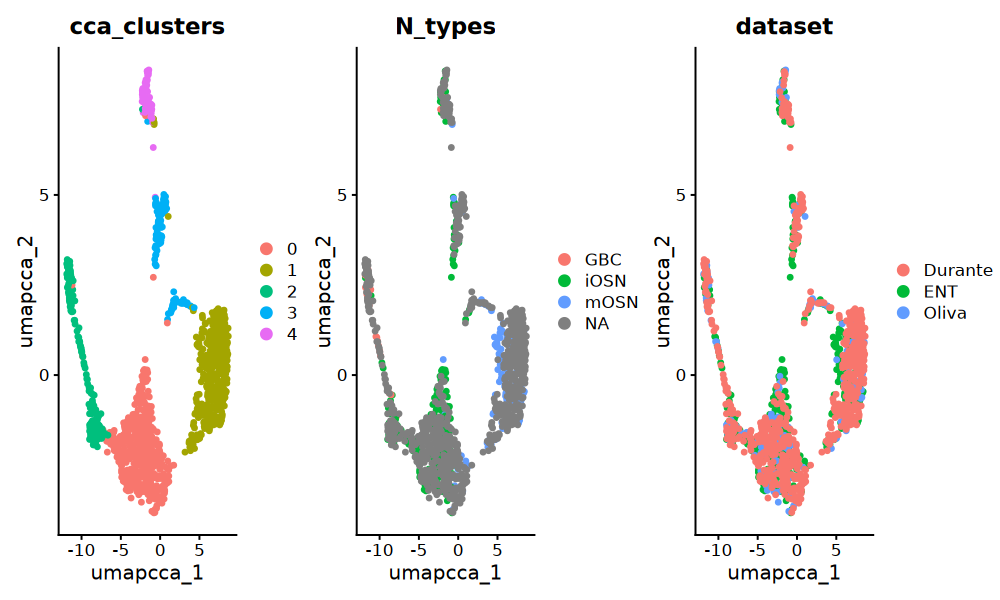

In [73]:
# label
obj <- cca_func(n_pc=10, n_feature=1000, n_neighbor=40, kw=50, method='cca', res=0.25)  
DimPlot(
  obj,
  reduction = "umap.cca",
  group.by = c('cca_clusters','N_types','dataset'),label.size = 2)

In [74]:
obj <- subset(obj, cca_clusters%in%c('0','1',"2"))
ent_goldstein <- ent_goldstein[,colnames(obj)]

In [75]:

n_features <- c(2000, 3000)##
n_pcs <- c( 30)#6, 10, 20,
n_neighbors <- c(30)
n_kweight <- c(50)
methods <- c('cca')

for (n_pc in n_pcs){
  for (n_feature in n_features){
    for (n_neighbor in n_neighbors){
      for(kw in n_kweight){
          for(method in methods){
              cca_func(n_pc, n_feature, n_neighbor, kw, method,res=0.4)  
          }
      }
    }
  }
}


Normalizing layer: counts.ENT

Normalizing layer: counts.Oliva

Normalizing layer: counts.DuranteGSM4142871_Patient2

Normalizing layer: counts.DuranteGSM4142872_Patient3

Finding variable features for layer data.ENT

Finding variable features for layer data.Oliva

Finding variable features for layer data.DuranteGSM4142871_Patient2

Finding variable features for layer data.DuranteGSM4142872_Patient3

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1064
Number of edges: 67028

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8180
Number of communities: 3
Elapsed time: 0 seconds


11:51:26 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:26 Read 1064 rows and found 30 numeric columns

11:51:26 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:26 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:51:26 Writing NN index file to temp file /tmp/RtmplTzX5F/file1a85163b0d73db

11:51:26 Searching Annoy index using 1 thread, search_k = 3000

11:51:26 Annoy recall = 100%

11:51:27 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:51:29 Initializing from normalized Laplacian +

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1064
Number of edges: 66935

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8182
Number of communities: 4
Elapsed time: 0 seconds


11:51:39 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:39 Read 1064 rows and found 30 numeric columns

11:51:39 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:39 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:51:39 Writing NN index file to temp file /tmp/RtmplTzX5F/file1a851658fc97c9

11:51:39 Searching Annoy index using 1 thread, search_k = 3000

11:51:39 Annoy recall = 100%

11:51:40 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:51:41 Initializing from normalized Laplacian +

In [76]:
obj <- cca_func(n_pc=30, n_feature=3000, n_neighbor=30, kw=50, method='cca',res=0.4)  


Normalizing layer: counts.ENT

Normalizing layer: counts.Oliva

Normalizing layer: counts.DuranteGSM4142871_Patient2

Normalizing layer: counts.DuranteGSM4142872_Patient3

Finding variable features for layer data.ENT

Finding variable features for layer data.Oliva

Finding variable features for layer data.DuranteGSM4142871_Patient2

Finding variable features for layer data.DuranteGSM4142872_Patient3

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1064
Number of edges: 66935

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8182
Number of communities: 4
Elapsed time: 0 seconds


11:51:51 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:51 Read 1064 rows and found 30 numeric columns

11:51:51 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

11:51:51 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:51:51 Writing NN index file to temp file /tmp/RtmplTzX5F/file1a8516756e14ca

11:51:51 Searching Annoy index using 1 thread, search_k = 3000

11:51:52 Annoy recall = 100%

11:51:52 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:51:54 Initializing from normalized Laplacian +

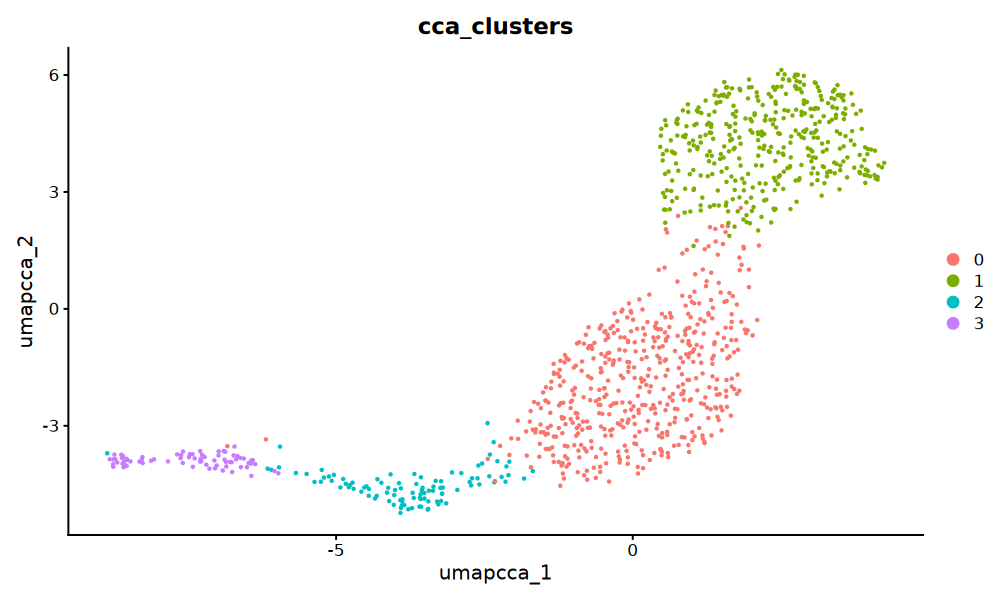

In [77]:
DimPlot(obj,  group.by  = "cca_clusters"  ,pt.size = 0.2)

An object of class Seurat 
19913 features across 1064 samples within 1 assay 
Active assay: RNA (19913 features, 3000 variable features)
 9 layers present: counts.ENT, counts.Oliva, counts.DuranteGSM4142871_Patient2, counts.DuranteGSM4142872_Patient3, data.ENT, data.Oliva, data.DuranteGSM4142871_Patient2, data.DuranteGSM4142872_Patient3, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap.cca

In [78]:
# Single-cell transcriptomics reveals receptor transformations during olfactory neurogenesis
# for progenitors, Ascl1 (achaete-scute complex homolog 1); for precursors, Neurog1 (neurogenin 1) and/or Neurod1 (neurogenic differentiation 1);
GBCinp <-  c("HES6","CXCR4","NEUROD1","NEUROG1")
GBCprogenitors <- c('ASCL1','MKI67','TOP2A')
iOSN <- c('GNG8', 'GAP43','LHX2','SOX4')#c('EBF2', 'EMX2')
p1 <- FeaturePlot(obj, features = GBCinp[1],  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)
p2 <- FeaturePlot(obj, features = GBCinp[2],  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)
p3 <- FeaturePlot(obj, features = GBCinp[3],  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)
p4 <- FeaturePlot(obj, features = GBCinp[4],  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)
p5 <- FeaturePlot(obj, features = "LHX2",  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)
p6 <- FeaturePlot(obj, features = "GAP43",  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )+theme_void()+theme(legend.position = '', aspect.ratio = 1)

px <- cowplot::plot_grid(p1,p2,p3,p4,nrow=2)
pX2 <- cowplot::plot_grid(p3,p4,p5,p6,nrow=2)

#FeaturePlot(obj, features = GBCprogenitors , cols = c("#FFF5F0",'#F75D42', "#6A010D") )+theme_minimal()+theme_void()+theme(legend.position = '')
#ggsave(px, file=paste0('./figures/NC/03GBC_markers.pdf'), width=5, height=5)    
#ggsave(pX2, file=paste0('./figures/NC/03GBC_markers2.pdf'), width=5, height=5)    

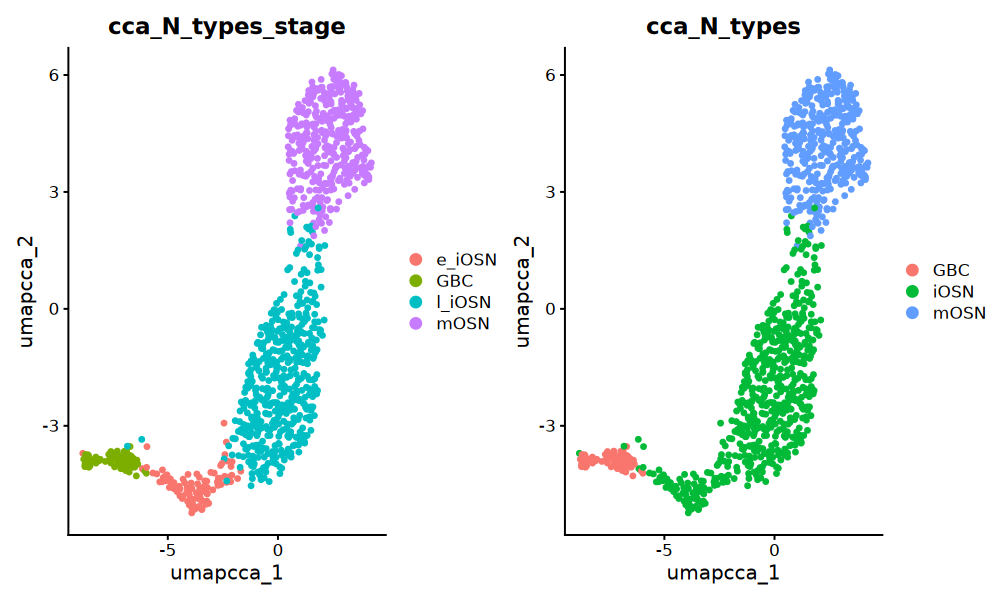

In [79]:
# # #obj <- FindNeighbors(obj, reduction = "integrated.cca", dims = 1:n_pc)
# obj <- FindClusters(obj, resolution = 0.25, cluster.name = "cca_clusters")

# obj <- RunUMAP(obj, reduction = "integrated.cca", dims = 1:n_pc, reduction.name = "umap.cca", n.neighbors=n_neighbor)

# DimPlot(
#   obj,
#   reduction = "umap.cca",
#   group.by = c('cca_clusters'),label.size = 2
# )

cca_label  <- c( 'GBC','e_iOSN','l_iOSN','mOSN')
names(cca_label) <- c('3','2','0','1')
obj <- RenameIdents(obj, cca_label)
obj@meta.data$cca_N_types_stage <- cca_label[as.character(obj$cca_clusters)]

obj@meta.data$cca_N_types <- ifelse(obj@meta.data$cca_N_types_stage%in%c('e_iOSN','l_iOSN'),'iOSN',obj@meta.data$cca_N_types_stage)

DimPlot(
  obj,
  reduction = "umap.cca",
  group.by = c('cca_N_types_stage', 'cca_N_types'),label.size = 2
)

saveRDS(obj,'/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_goldstein_merge_cca.rds')
#ent_N <- readRDS('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_goldstein_merge_cca.rds')

In [80]:
ent_N <- readRDS('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_goldstein_merge_cca.rds')

In [81]:
table(ent_N@meta.data$dataset)


Durante     ENT   Oliva 
    601     325     138 

In [82]:
# library(dplyr)
# library(Seurat)
# library(patchwork)
# library(slingshot)
# VlnPlot(
#   subset(ent_N,dataset=='Durante' ),
#   c('LHX2','PAX6','SHANK3','TCF4','SHANK2'),sort = T)

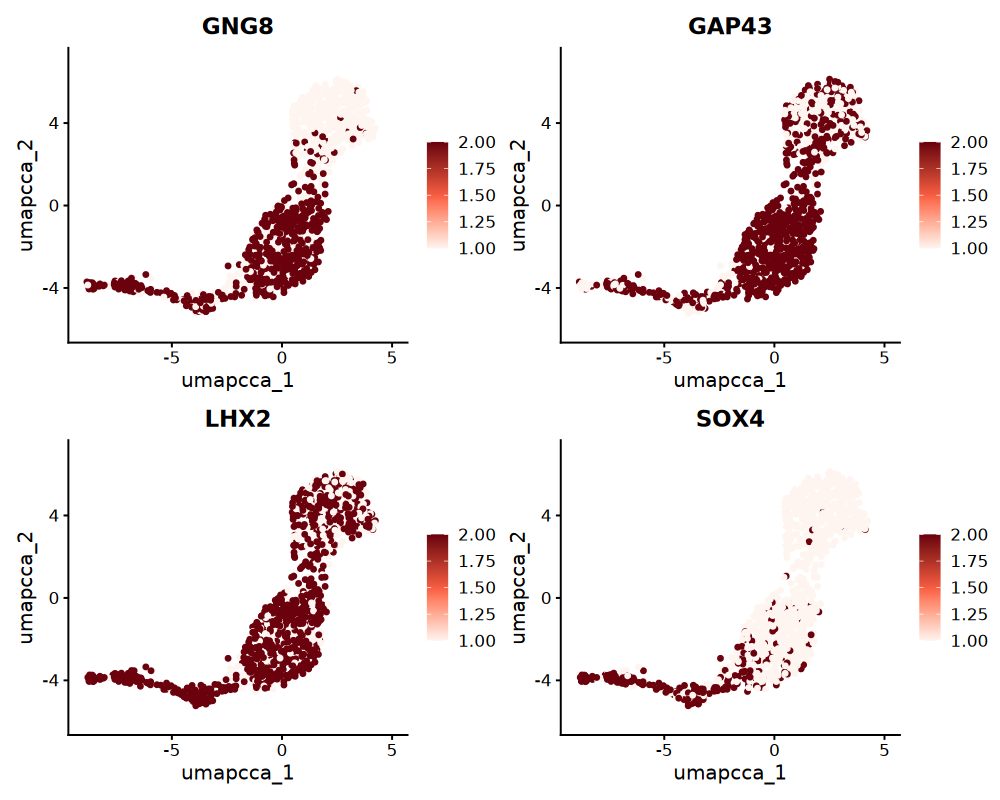

pdf 
  2

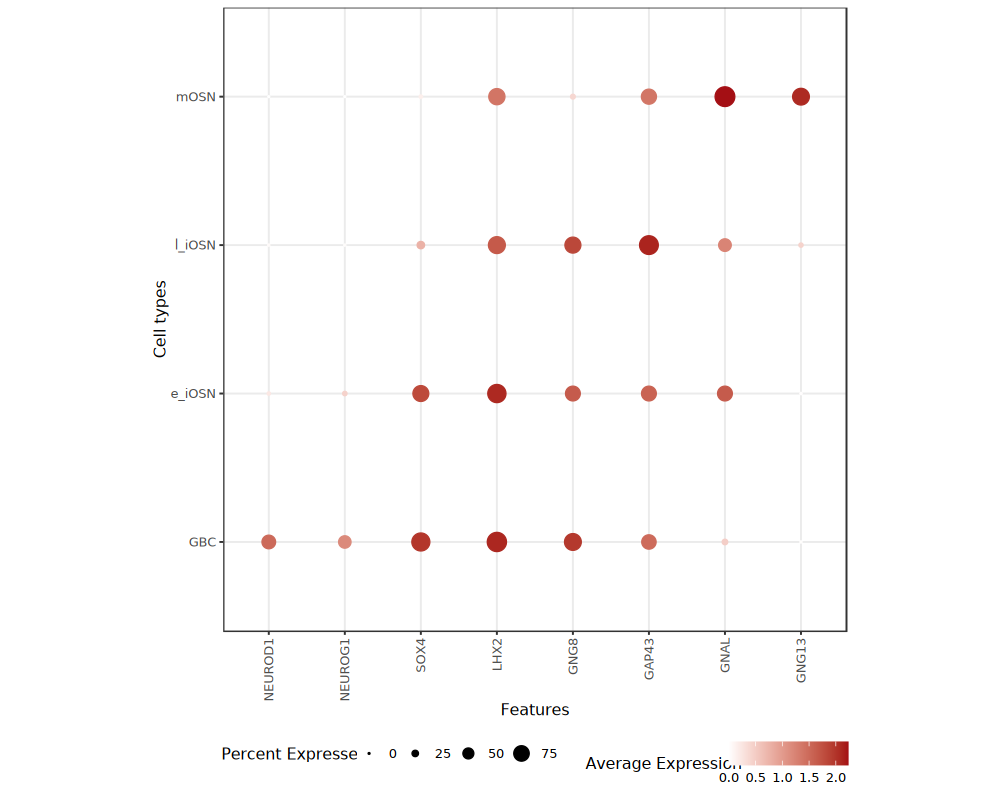

In [84]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 100)

FeaturePlot(obj, features = iOSN,  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )#+theme( aspect.ratio = 1)

DotPlot(obj, features = c('NEUROD1','NEUROG1','SOX4','LHX2','GNG8','GAP43','GNAL','GNG13'), 
        cols = c("white", "#A40F14"),scale = FALSE) + RotatedAxis()+theme_bw()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),legend.position = 'bottom',aspect.ratio = 1)+ylab('Cell types')

dev.print(pdf,file = "/sc/arion/projects/roussp01a/liting/Olf/figures/NC/marker_dot.pdf", width = 3.5, height = 5)


pdf 
  2

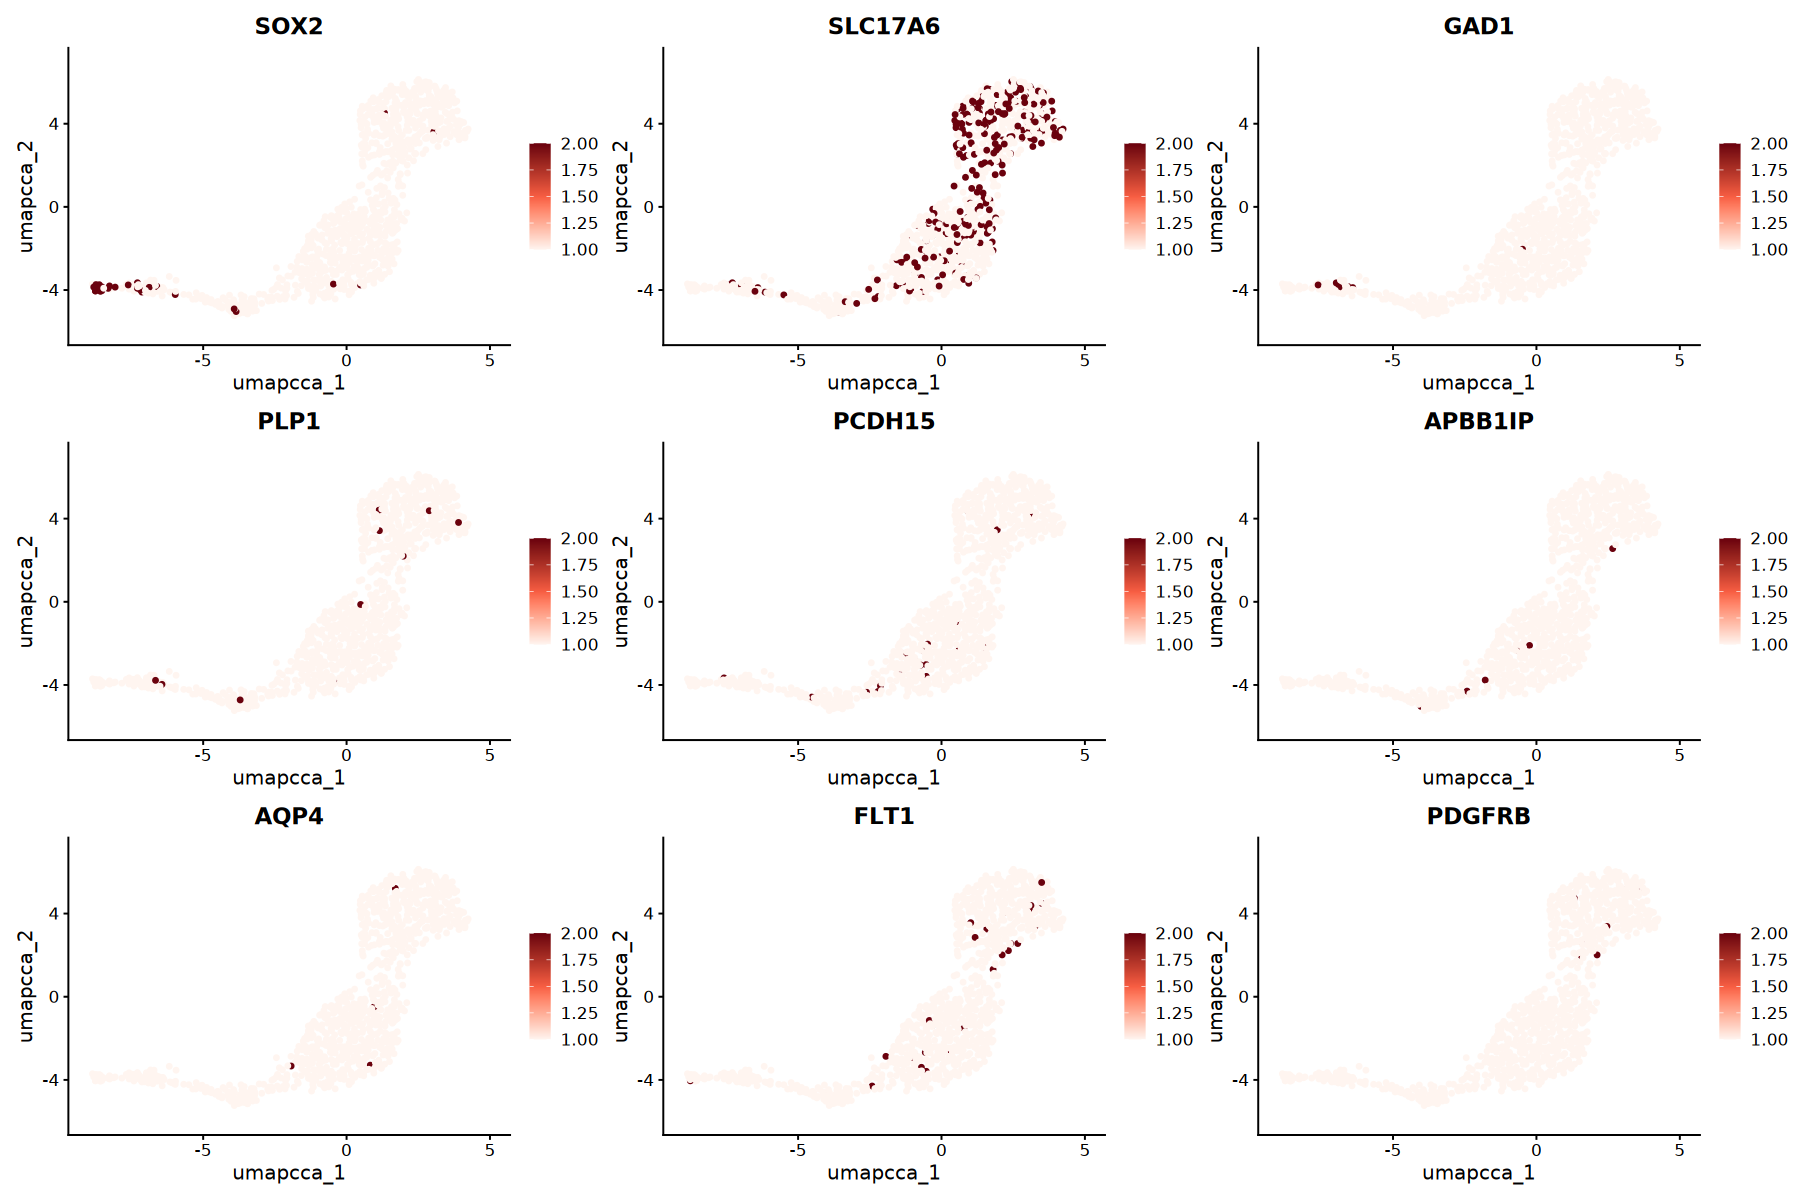

In [108]:
FeaturePlot(obj, features = c('SOX2','SLC17A6','GAD1','PLP1','PCDH15','APBB1IP','AQP4','FLT1','PDGFRB'),  cols = c("#FFF5F0",'#F75D42', "#6A010D")  )
dev.print(pdf, file="/sc/arion/projects/roussp01a/liting/Olf/figures/NC/marker_brain.pdf", width = 10, height = 7)

In [25]:
obj@meta.data$Age[obj@meta.data$donor_name%in%c('GSM4142871_Patient2')] <- 52
obj@meta.data$Age[obj@meta.data$donor_name%in%c('GSM4142872_Patient3')] <- 44
obj@meta.data$Age[obj@meta.data$donor_name%in%c('GSM5578174_H2020_8')] <- 71
obj@meta.data$Age[obj@meta.data$donor_name%in%c('GSM5578175_H2021_17')] <- 66
obj@meta.data$Age[obj@meta.data$donor_name%in%c('GSM5578176_H2021_12')] <- 51

obj@meta.data$Sex<- ifelse(obj@meta.data$Sex=='Female',0,1)
obj@meta.data$Sex[obj@meta.data$donor_name%in%c('GSM4142871_Patient2')] <- 1
obj@meta.data$Sex[obj@meta.data$donor_name%in%c('GSM4142872_Patient3')] <- 0
obj@meta.data$Sex[obj@meta.data$donor_name%in%c('GSM5578174_H2020_8')] <- 0
obj@meta.data$Sex[obj@meta.data$donor_name%in%c('GSM5578175_H2021_17')] <- 0
obj@meta.data$Sex[obj@meta.data$donor_name%in%c('GSM5578176_H2021_12')] <- 1


In [ ]:
write.csv(obj@meta.data, file='./data/ent_goldstein_merge_cca.metadata.csv')

In [137]:
obj_combined <- JoinLayers(object = obj)
#markers_2 <- FindMarkers(CB30_combined, ident.1 = "CD4+", ident.2 = "CD4+ UT", verbose = FALSE)


Idents(obj_combined) <- "cca_N_types_stage"
GBC.de.markers <- FindMarkers(obj_combined, ident.1 = "GBC", ident.2 = NULL, only.pos = TRUE)%>%subset(p_val_adj < 0.05)
e_iOSN.de.markers <- FindMarkers(obj_combined, ident.1 = "e_iOSN", ident.2 = NULL, only.pos = TRUE)%>%subset(p_val_adj < 0.05)
l_iOSN.de.markers <- FindMarkers(obj_combined, ident.1 = "l_iOSN", ident.2 = NULL, only.pos = TRUE)%>%subset(p_val_adj < 0.05)
mOSN.de.markers <- FindMarkers(obj_combined, ident.1 = "mOSN", ident.2 = NULL, only.pos = TRUE)%>%subset(p_val_adj < 0.05)

mOSN.de.markers[1:3,]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GNG13,9.979907e-132,4.091478,0.820,0.101,1.987299e-127
STOML3,2.354967e-129,4.308561,0.774,0.056,4.689445e-125
GNAL,9.573301e-121,1.731978,0.987,0.567,1.906331e-116


In [138]:
e_l_iOSN_DEG <- FindMarkers(obj_combined, ident.1 = "e_iOSN", ident.2 = "l_iOSN", verbose = FALSE)%>%subset(p_val_adj < 0.05)


In [242]:
path_eiOSN <- (gost(rownames(subset(e_l_iOSN_DEG,avg_log2FC > log2(1.5) )), source='GO:BP' ,
                 correction_method = "fdr",user_threshold=0.1,significant=F)$result %>%subset(term_size < 2000 & term_size > 100 & p_value < 0.05))#[1:10,]


In [243]:
path_liOSN <-(gost(rownames(subset(e_l_iOSN_DEG,avg_log2FC < -log2(1.5) )), source='GO:BP' ,
                 correction_method = "fdr",user_threshold=0.1,significant=F)$result %>%subset(term_size < 2000 & term_size > 100 & p_value < 0.05))#[1:10,]

In [245]:
path_eiOSN$query <- 'e_iOSN'
path_liOSN$query <- 'l_iOSN'

path_iOSN <- rbind(path_eiOSN, path_liOSN)
colnames(path_iOSN)[3] <- 'fdr'

In [246]:
write.table(path_iOSN[,c('query','term_name','fdr')], file='./data/NC/supple_path_iOSN.txt',sep='\t', quote=F)


In [87]:
#png(filename = "./figures/NC/outermerge_mnc3_pseudotime.png",width = 10, height = 8, units = "cm", res=300)
options(repr.plot.width = 12, repr.plot.height = 12, repr.plot.res = 100)

library(scattermore)#scattermore
UMAPCCA <- as.data.frame(obj@reductions$umap.cca@cell.embeddings)
UMAPCCA$dataset <- obj$dataset
UMAPCCA$N_types <- obj$N_types
UMAPCCA$N_types_stage <- obj$cca_N_types_stage

brewer.pal(n = 12, name = "Paired")

p1 <- ggplot(UMAPCCA, aes(x=umapcca_1,y=umapcca_2, color=N_types ))+
geom_scattermore(pointsize=5)+theme_bw()+theme(aspect.ratio = 1)+
scale_color_manual(values =  c('#1f77b4','#ff7f0e',"#D32B29"),breaks = c('GBC','iOSN','mOSN'))+xlab('UMAP1')+ylab('UMAP2')

p1 <- ggplot(UMAPCCA, aes(x=umapcca_1,y=umapcca_2, color=factor(N_types_stage,levels = c('GBC','e_iOSN','l_iOSN','mOSN') )))+
geom_scattermore(pointsize=5)+theme_bw()+theme(aspect.ratio = 1)+labs(col='Cell types')+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),
                   breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+xlab('UMAP1')+ylab('UMAP2')+
theme(panel.grid.major = element_blank(), 
      panel.grid.minor = element_blank(),
    axis.text = element_blank(),    # Remove axis text
    axis.ticks = element_blank()
     )

UMAPCCA$dataset <- factor(UMAPCCA$dataset, levels = c('ENT','Durante','Oliva'))
p2 <- ggplot(UMAPCCA, aes(x=umapcca_1,y=umapcca_2, color=dataset ))+xlab('UMAP1')+ylab('UMAP2')+geom_scattermore(pointsize=5)+theme_bw()+theme(aspect.ratio = 1)+
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
          axis.text = element_blank(),    # Remove axis text
    axis.ticks = element_blank()
 )+scale_color_manual(values =  c('#1f77b4','#ff7f0e',"#D32B29"))

pdf(file='./figures/NC/03ent_goldstein_N_merge.umap.pdf',width=8, height=3.5)
p2+p1
dev.off()

[1] "#A6CEE3" "#1F78B4" "#B2DF8A" "#33A02C" "#FB9A99" "#E31A1C" "#FDBF6F"
 [8] "#FF7F00" "#CAB2D6" "#6A3D9A" "#FFFF99" "#B15928"

pdf 
  2

In [86]:
unique(UMAPCCA$dataset)

[1] "ENT"     "Oliva"   "Durante"

### slingshot

In [30]:
sling_merge <- get_slingshot_traj(obj=obj)

In [37]:
data_ns <- read_obj('ent_Goldstein_merge', hvg = 3000)
data_ns=data_ns[!grepl('^RPS|^RPL|^LINC|^MT',rownames(data_ns)),]
data_ns <- data_ns[, colnames(obj)]
data_ns@meta.data <- obj@meta.data
data_ns@meta.data$sling_pseudotime <- sling_merge$sling_pseudotime


In [38]:
DEG_sling_merge2 <- tradeseq_DEG(data_ns=data_ns, 'slingshot') 

In [ ]:
get_bg <- function(celltype){
    data_sub <- subset(data_ns, cca_N_types_stage=='GBC')
    custom_olfbg <- rownames(data_sub)[rowSums(as.data.frame(data_sub@assays$RNA@counts > 0)) > 0.05*ncol(data_sub)]
    return(custom_olfbg)
}

custom_olfbg <- lapply(c('GBC','e_iOSN','l_iOSN','mOSN'),get_bg)
custom_olfbg <- unique(unlist(custom_olfbg))

custom_olfbg <- rownames(data_ns)[rowSums(as.data.frame(data_ns@assays$RNA@counts > 0)) > 0.05*ncol(data_ns)]
custom_olfbg <- rownames(data_ns)[rowSums(as.data.frame(data_ns@assays$RNA@counts > 0)) >= 5]

#save(custom_olfbg, file='./data/custom_olfbg.RData')


### monocle3 

In [212]:
# for(ncent in seq(80,150, by = 1)){
#     data_ns@reductions$umap <- obj@reductions$umap.cca
#     int_N <- get_monocle3_traj(scdata=data_ns,'x','min',res_traj=0.01, ncent = ncent)
#     p <- plot_cells(int_N, color_cells_by = "pseudotime",  cell_size = 0.8,label_roots=F,label_branch_points=F,label_leaves=F)+theme(legend.position = 'top', aspect.ratio = 1)

#     ggsave(p, file=paste0('./figures/NC/mnc',ncent,'.pdf'))
# }


In [234]:
 int_N <- get_monocle3_traj(scdata=data_ns,'x','min',res_traj=0.01, ncent = 145)
 p <- plot_cells(int_N, color_cells_by = "pseudotime",  cell_size = 0.8,label_roots=F,label_branch_points=F,label_leaves=F)+theme(legend.position = 'top', aspect.ratio = 1)


  |======================================================================| 100%
[1] "-------------check root cell based on umap--------------------"


Cells aren't colored in a way that allows them to be grouped.

Cells aren't colored in a way that allows them to be grouped.



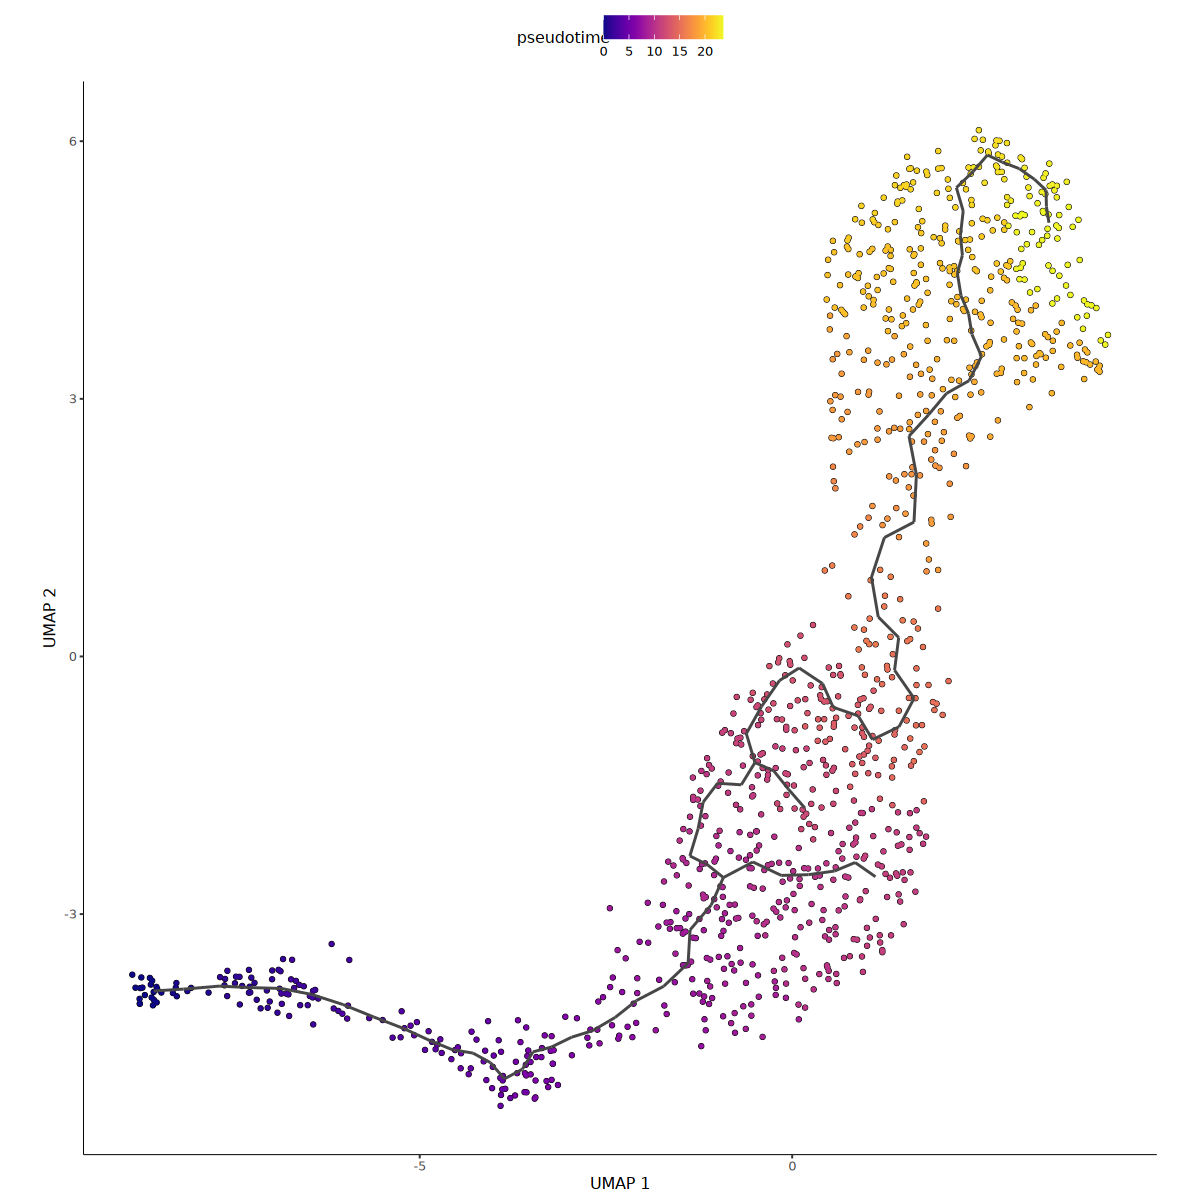

In [242]:
p

Cells aren't colored in a way that allows them to be grouped.



pdf 
  2

pdf 
  2

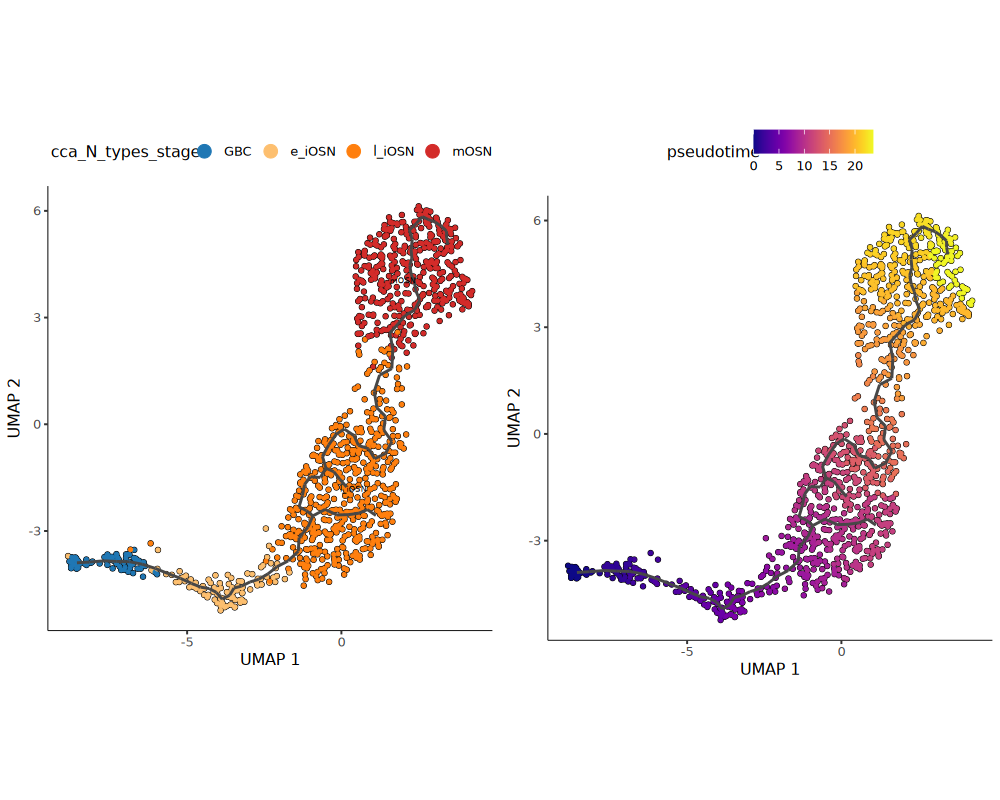

In [339]:
save(int_N, file='./figures/NC/mnc3_ent_goldstein.RData')

p1 <- plot_cells(int_N, color_cells_by = "pseudotime",  cell_size = 0.8,label_roots=F,label_branch_points=F,label_leaves=F)+theme(legend.position = 'top', aspect.ratio = 1)
p2 <- plot_cells(int_N, color_cells_by = "cca_N_types_stage",  cell_size = 0.8,label_roots=F,label_branch_points=F,label_leaves=F)+
#scale_color_manual(values =  c('#1f77b4','#ff7f0e',"#D32B29"),breaks = c('GBC','iOSN','mOSN'))+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+
theme(legend.position = 'top', aspect.ratio = 1)
cowplot::plot_grid(p2,p1,nrow = 1)

pdf( "./figures/NC/03outermerge_mnc3_pseudotime_NCp1.pdf",width = 4, height = 4)
p1
dev.off()

pdf( "./figures/NC/03outermerge_mnc3_pseudotime_NCp2.pdf",width = 4, height = 4)
p2
dev.off()

In [245]:
getwd()

[1] "/sc/arion/projects/roussp01a/liting/Olf"

In [285]:
save(int_N, file='./figures/NC/mnc3_ent_goldstein.RData')


In [246]:
data_ns$monocle3_pseudotime <- pseudotime(int_N)
int_N$monocle3_pseudotime <-  pseudotime(int_N)
#DEG_mnc3_int_glm <- get_monocle3_DEG_contBatch(int_N)

In [251]:
DEG_mnc3_int_graph <- get_monocle3_DEG(int_N)
DEG_mnc3_int_graph

  |=======================================================| 100%, Elapsed 16:56


DataFrame with 19913 rows and 5 columns
              status   p_value morans_test_statistic   morans_I   q_value
         <character> <numeric>             <numeric>  <numeric> <numeric>
ACSM4             OK         0               42.9413   0.416827         0
ADCY3             OK         0               42.1556   0.409175         0
ARPP21            OK         0               39.2333   0.380717         0
BTBD17            OK         0               49.1794   0.477576         0
C11orf97          OK         0               52.4038   0.508976         0
...              ...       ...                   ...        ...       ...
PTCD2             OK  0.994257              -2.52757 -0.0259676  0.994457
ANKRD24           OK  0.994953              -2.57259 -0.0264060  0.995103
NEB               OK  0.995687              -2.62651 -0.0269311  0.995787
ZFP3              OK  0.998361              -2.94034 -0.0299873  0.998411
PPP1R3D           OK  0.999271              -3.18294 -0.0323498  0.99927

In [53]:
library(ggsci)

In [232]:
#write.table(data_ns@meta.data[,c('cca_N_types_stage','dataset','sling_pseudotime','monocle3_pseudotime')], file='')

pdf 
  2

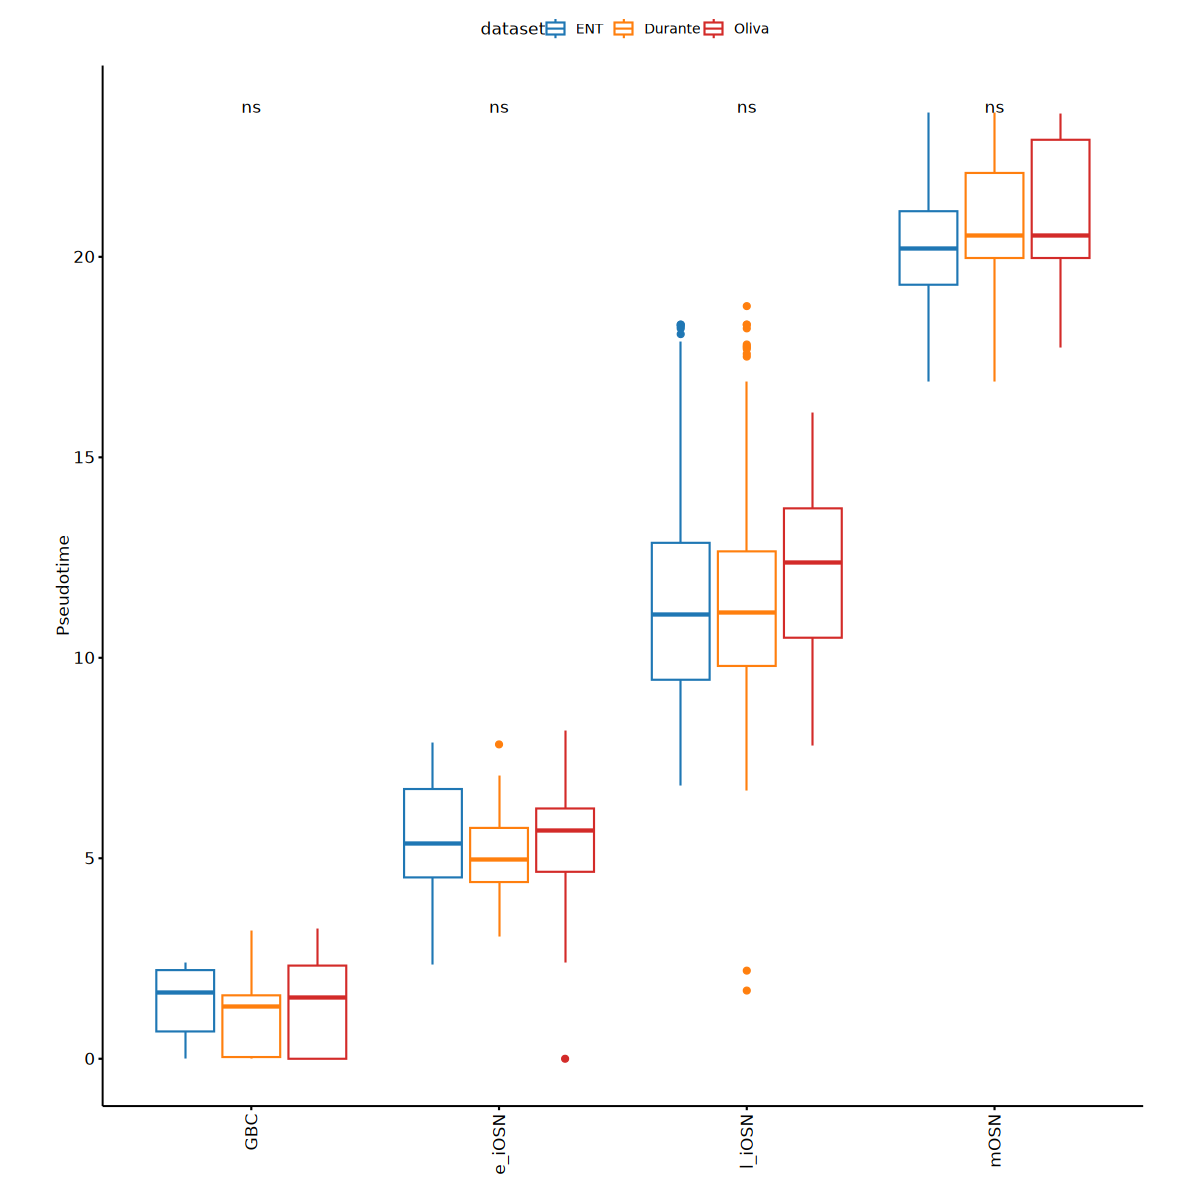

In [88]:
library(ggplot2)
library(ggsignif)  # For adding significance tests
library(ggpubr)
N_stage_color <- c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29")
names(N_stage_color) <- c('GBC','e_iOSN','l_iOSN','mOSN')
data_ns@meta.data$dataset <- factor(data_ns@meta.data$dataset, levels = c('ENT','Durante','Oliva' ))

data_ns@meta.data$cca_N_types_stage <- factor(data_ns@meta.data$cca_N_types_stage, levels = c('GBC','e_iOSN','l_iOSN','mOSN'))
ggboxplot(data_ns@meta.data, x = "cca_N_types_stage", y = "monocle3_pseudotime",
          color = "dataset", 
          )+stat_compare_means(aes(group = dataset), method = "anova",label = "p.signif")+ylab('Pseudotime') +xlab('')+
#scale_color_manual(values =  c('#2D81BC','#B8B8B8'))+
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),aspect.ratio = 1)+scale_color_manual(values =  c('#1f77b4','#ff7f0e',"#D32B29"))

dev.print(pdf, file='./figures/NC/pseudo_boxplot_NC.pdf',height=3.8,width=3.5)

In [234]:
write.table(data_ns@meta.data[,c('cca_N_types_stage','dataset','sling_pseudotime','monocle3_pseudotime')], 
            file='./data/NC/f2c.pseudotime.txt', sep='\t',quote=F)

pdf 
  2

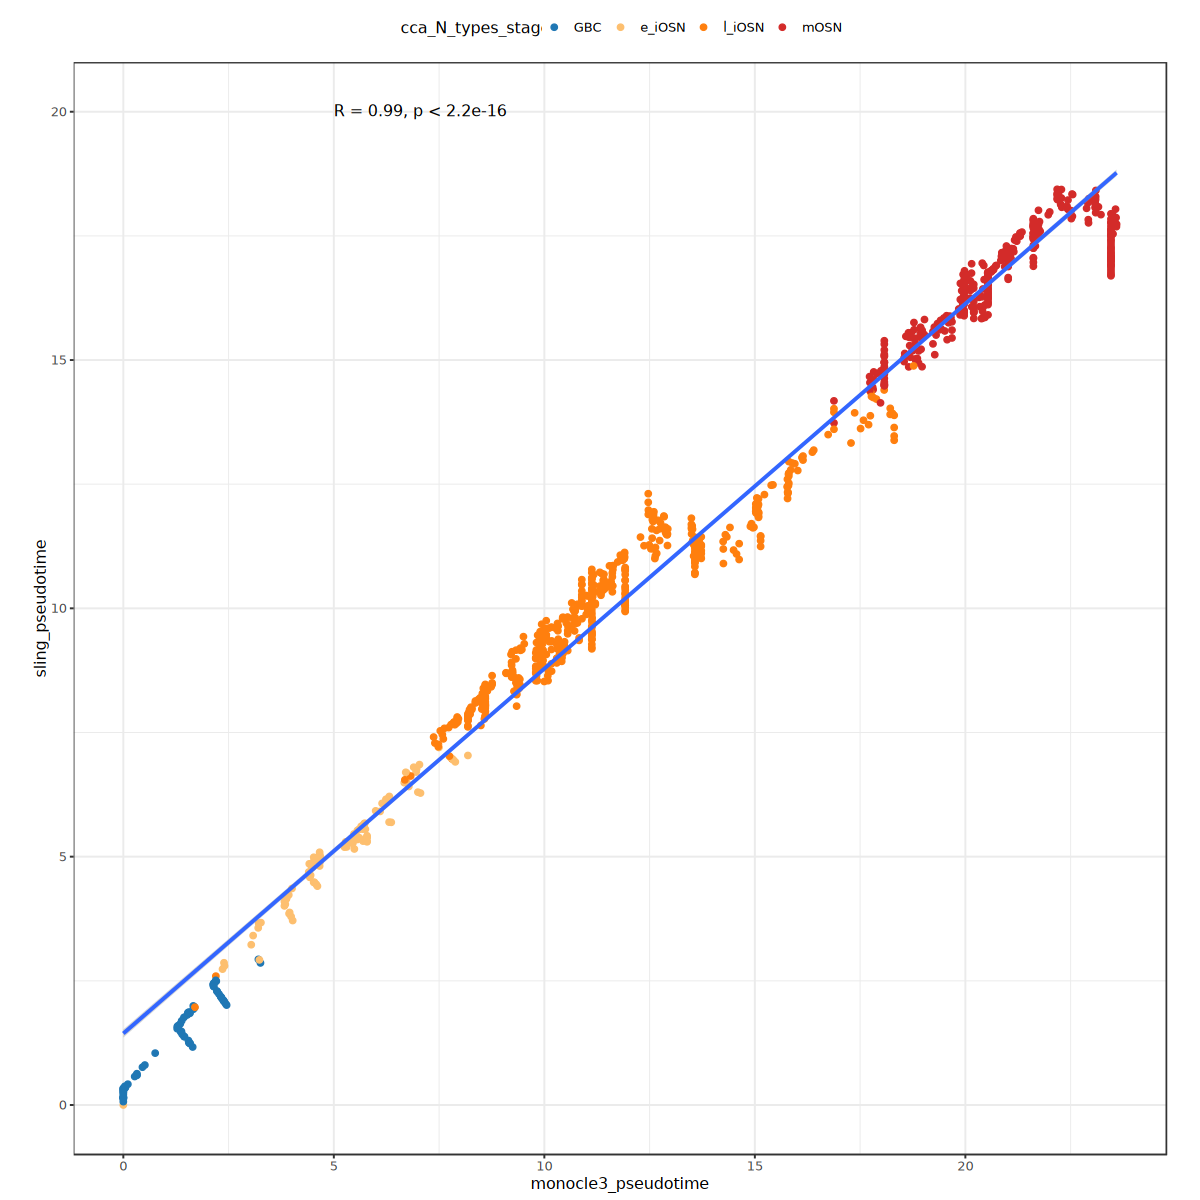

In [276]:
#Scatter plot with correlation coefficient
library(ggpubr) 
ggplot(data_ns@meta.data, aes(x=monocle3_pseudotime ,y=sling_pseudotime))+geom_point(aes(color=cca_N_types_stage))+
theme_bw()+scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+
theme(legend.position = 'top', aspect.ratio = 1)+
stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") +
stat_cor(method = "spearman", label.x = 5, label.y = 20)

dev.print(pdf, file= "./figures/NC/03mnc3_slingshot_pseudotime_nc.pdf",width = 4, height = 4)

In [277]:
write.table(data_ns@meta.data, file='./data/integrate_entgoldstein_pseduotime_meta.txt',sep='\t',quote=F)

In [204]:

load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')# previous data DEGs

In [268]:
save(DEG_mnc3_int_graph,DEG_sling_merge2, file='./data/DEG_ENTgs.RData' )

In [205]:
load('./data/DEG_ENTgs.RData')
DEGs1 <- rownames(subset(DEG_mnc3_int_graph, morans_I > 0.05 &  q_value < 0.05))

In [206]:
pdf("/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_diagram_slingshot_moran.pdf", width = 6, height = 6)

library(VennDiagram) 
v1 <- venn.diagram(list(
  `TradeSeq` = rownames(subset(DEG_sling_merge2,fdr < 0.05 & meanLogFC > log2(1.3))),
  `Moran's I` = rownames(subset(DEG_mnc3_int_graph, q_value < 0.05 & morans_I > 0.05 ))#, 
  ), fill = c("#0073C2FF", "#EFC000FF"), 
             alpha = c(0.5, 0.5), lwd =0, filename = NULL#,#"./figures/NC/venn_diagram_slingshot_moran.png"
            )
grid.draw(v1)
dev.off()

pdf("/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_diagram_v1v2.pdf", width = 6, height = 6)

library(VennDiagram) 
v2 <- venn.diagram(list(
  'Primary data' = rownames(DEG_trend_Olf),
  'Extended data' = rownames(subset(DEG_mnc3_int_graph, q_value < 0.05 & morans_I > 0.05 ))#, 
  ), fill = c("#0073C2FF", "#EFC000FF"), 
             alpha = c(0.5, 0.5), lwd =0, filename = NULL#"./figures/NC/venn_diagram_v1v2.png"
            )

grid.draw(v2)
dev.off()

pdf 
  2

pdf 
  2

In [251]:
write.table(rownames(subset(DEG_sling_merge2,fdr < 0.05 & meanLogFC > log2(1.3))),file='./data/NC/Tradeseq_deg.txt', quote = F)
write.table(rownames(subset(DEG_mnc3_int_graph, q_value < 0.05 & morans_I > 0.05 )),file='./data/NC/morans_I_deg.txt', quote = F)

### Gene clusters

In [5]:
#rownames(subset(DEG_sling_merge2,fdr < 0.05))
#library(dreamlet)
#load('./data/variance_partition.RData')
#intersect(DEGs1, subset(res.vp,assay=='OSNs' & smoke > 0.05)$gene)
load('./data/smoking_genes.RData')

In [122]:
length(DEGs)

[1] 2140

In [10]:
DEGs <-   setdiff(DEGs1, smoking_genes ) #intersect(DEGs1,rownames(subset(DEG_sling_merge2,fdr < 0.05)))
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 100)

In [344]:
scdata <- data_ns
save(scdata, file='./data/scdata.RData') 

In [50]:
load('./data/scdata.RData')

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



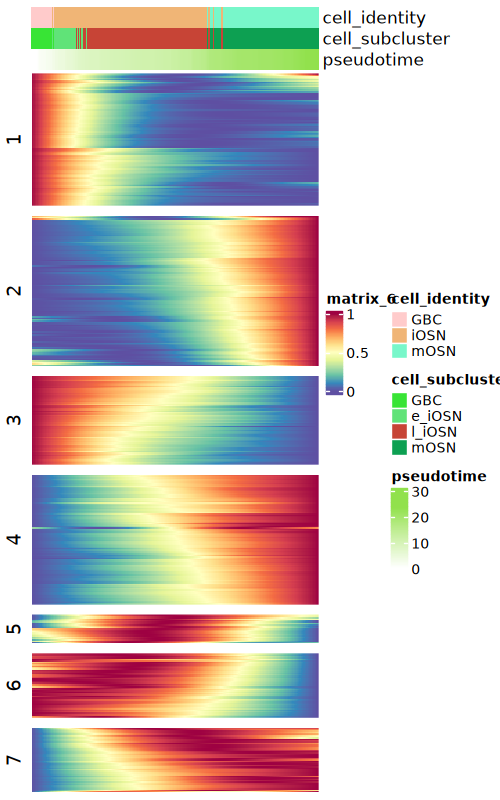

In [213]:
library(ComplexHeatmap)
#pseudoTime = scdata$sling_pseudotime#
pseudoTime =  scdata$monocle3_pseudotime

pt.matrix1 <- as.matrix(scdata@assays$RNA@counts[DEGs,order(pseudoTime)])
pt.matrix <- t(apply(pt.matrix1,1,function(x){smooth.spline(x,df=3)$y}))
#pt.matrix <- t(apply(pt.matrix,1,function(x){(x-mean(x))/sd(x)}))
pt.matrix <- t(apply(pt.matrix,1,function(x){(x-min(x))/(max(x)-min(x))}))

rownames(pt.matrix) <- DEGs;
colnames(pt.matrix) <- colnames(scdata)[order(pseudoTime)]

n_cluster <- 7

set.seed(011)

heatmap_cluster <- Heatmap(
  pt.matrix,
  row_km =n_cluster,
  col                          = colorRamp2(seq(from=0,to=1,length=11),rev(brewer.pal(11, "Spectral"))),
  #row_title = "cluster_%s",
  row_gap = unit(c(2.5), "mm"),
  cluster_row_slices = F,
  cluster_columns              = F,
  show_row_names               = FALSE,
  show_column_names            = FALSE,
  show_row_dend = F,
  top_annotation = HeatmapAnnotation(
    cell_identity=scdata@meta.data[colnames(pt.matrix),'cca_N_types'],
    cell_subcluster=scdata@meta.data[colnames(pt.matrix),'cca_N_types_stage'],
    #batch=scdata@meta.data[colnames(pt.matrix),'batch'],
    #subc=scdata@meta.data[colnames(pt.matrix),'N_leiden_res0_2'],
    pseudotime=sort(pseudoTime)#,
    #col = list(cell_identity = N_color)
    # pseudotime= colorRamp2(c(0, 10, 20, 30), c("#35008C", "#8700A8", "#D3546F",'#E7F92D'))
  )
)
hthc=ComplexHeatmap::draw(heatmap_cluster)
hthc

#save(hthc,file = './figures/NC/heatmap_cluster_graphK7_vGs.RData')

In [214]:
#load('./figures/NC/heatmap_cluster_graphK7.RData')
DEG_trend_Olf <- c()

down_cl <- c(1,3)
trans_up_cl <- c(6,5,7)
up_cl <- c(4,2)
trans_down_cl <- c()

# down_cl <- c(1,2,4)
# trans_up_cl <- c(7,6)
# up_cl <- c(5,3)
# trans_down_cl <- c()

for(cl in 1:n_cluster){
    deg_td <- cbind(DEGs[row_order(hthc)[[cl]]], cl )
    
    DEG_trend_Olf <- rbind(DEG_trend_Olf, deg_td )
}
DEG_trend_Olf <- as.data.frame(DEG_trend_Olf)
colnames(DEG_trend_Olf) <- c('gene','cl')


DEG_trend_Olf <-  within(DEG_trend_Olf,{
    trend_class=''
    trend_class[cl%in%down_cl] <- 'down'
     trend_class[cl%in%trans_up_cl] <- 'trans_up'
     trend_class[cl%in%up_cl] <- 'up'
    trend_class[cl%in%trans_down_cl] <- 'trans_down'
    
})


order_c <- as.character(c(down_cl,trans_up_cl,up_cl,trans_down_cl ))
#order_c <- as.character(c(6,2,7,1,4,5,3))
order_n <- c(1:length(order_c))
names(order_c) <-   order_n    

order_c <- sort(order_c)
order_n <- names(order_c)

rownames(DEG_trend_Olf) <- DEG_trend_Olf$gene
DEG_trend_Olf$g_cluster <- as.character(order_n)[as.numeric(DEG_trend_Olf$cl)]
trend_color <- brewer.pal(n = 8, name = "Paired")[c(1,3,5,7)]
names(trend_color) <- c('down','trans_down','up','trans_up')

Nstage_color <- c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29")
names(Nstage_color) <- c('GBC','e_iOSN','l_iOSN','mOSN')



In [189]:
library(RColorBrewer)
brewer.pal(n = 8, name = "Paired")[c(1,3,5,7)]

[1] "#A6CEE3" "#B2DF8A" "#FB9A99" "#FDBF6F"

In [25]:
save(DEG_trend_Olf, file='/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph_entgoldstein.RData')

In [353]:
load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph_entgoldstein.RData')

In [26]:
supp_degs <- subset(DEG_mnc3_int_graph, morans_I > 0.05 &  q_value < 0.05)
supp_degs$trajDEG_cluster <- DEG_trend_Olf[rownames(supp_degs),'g_cluster']
supp_degs$trend_class <- DEG_trend_Olf[rownames(supp_degs),'trend_class']


In [236]:
write.table(supp_degs[,c('morans_I','q_value','trajDEG_cluster','trend_class')],file='./data/NC/supp_DEGs_entgoldstein.txt',sep='\t', quote = F)

In [27]:
write.table(DEG_trend_Olf, file='./data/DEG_trend_Olf_entgoldstein.txt',sep='\t')
table(DEG_trend_Olf$trend_class)


    down trans_up       up 
     717      513      910 

In [86]:
# get_bp_enrichr <- function(x){
#     query_gene <- subset(DEG_trend_Olf, g_cluster%in%as.character(x))[,'gene']
#     dbs <- "GO_Biological_Process_2023"
#     enriched <- enrichr(query_gene, dbs)
#     enrr <- enriched[['GO_Biological_Process_2023']]
#     return(enrr) 
# }


# enr <-  get_bp_enrichr(c(6,7))
# enr[1:35,]


In [87]:
#load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')

lister_hvg <- read.csv('lister_hvg.csv')
#
table(DEG_trend_Olf$gene%in%lister_hvg$X[lister_hvg$highly_variable=='True'])
#DEG_trend_Olf$gene


FALSE  TRUE 
 1285   491 

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



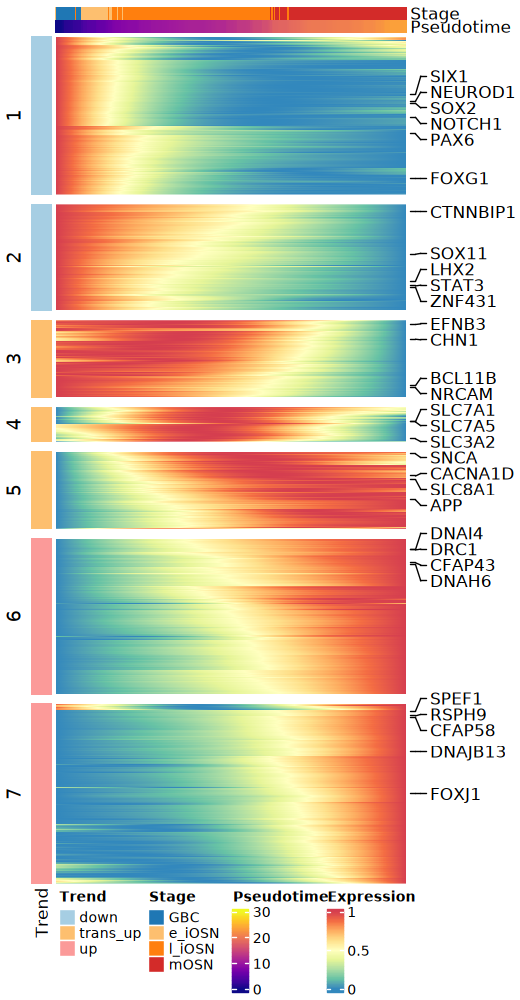

In [215]:
library(viridis)
ptm <- pt.matrix[unlist(row_order(hthc)[order_c] ),]
options(repr.plot.width = 5.2, repr.plot.height = 10, repr.plot.res = 100)

Nstage_color <- c( '#1f77b4','#FDBF6F','#ff7f0e',"#D32B29")
names(Nstage_color) <- c('GBC','e_iOSN','l_iOSN','mOSN' )

genes_to_show = unlist(strsplit(c("NEUROD1,NOTCH1,SOX2,SIX1,PAX6,FOXG1",
                                  "CTNNBIP1,ZNF431,SOX11,LHX2,STAT3",
                                 "EFNB3,CHN1,BCL11B,NRCAM",
                                 "SLC7A1,SLC7A5,SLC3A2",
                                 "SNCA,CACNA1D,SLC8A1,APP",
                                  "DNAI4,DRC1,CFAP43,DNAH6",
                                 "SPEF1,RSPH9,CFAP58,DNAJB13,FOXJ1"),','))
labels = rowAnnotation(foo = anno_mark(at =match(genes_to_show, rownames(ptm)) , 
                                      labels = genes_to_show))

hthc <- ComplexHeatmap::draw(Heatmap(
    ptm, name = "Expression",
    col    = colorRamp2(seq(from=0,to=1,length=9),rev(brewer.pal(9, "Spectral"))),
    row_gap = unit(c(2.5), "mm"),
    cluster_rows = FALSE,
    cluster_columns              = F,
    show_row_names               = FALSE,
    show_column_names            = FALSE,
    use_raster = TRUE, raster_quality = 5,
    show_row_dend = F,
    row_split = DEG_trend_Olf[rownames(ptm),'g_cluster'],
    #heatmap_legend_param = list(legend_width = unit(20, "cm"),title_gap = unit(10, "cm")),

    left_annotation = rowAnnotation(Trend = DEG_trend_Olf[rownames(ptm),'trend_class'],
                                     col=list(Trend = trend_color)),
    right_annotation = labels,
    top_annotation = HeatmapAnnotation(
      #Neuron = scdata@meta.data[colnames(pt.matrix),'cca_N_types'],
      Stage = factor(scdata@meta.data[colnames(pt.matrix),'cca_N_types_stage'],levels = c('GBC','e_iOSN','l_iOSN','mOSN')),
      Pseudotime=sort(pseudoTime),
      col = list(#Neuron = N_color,
                 Stage=Nstage_color ,
                 Pseudotime=colorRamp2(seq(from=0,to=30,length=50), plasma(50)) ),simple_anno_size = unit(0.3, "cm"))),
    heatmap_legend_side = "bottom", annotation_legend_side = "bottom",merge_legend = TRUE )



In [217]:
#png(filename = './figures/NC/03heatmap_DEG_clusters_k7.png', width = 15, height = 20, units = "cm", res=300)
pdf( './figures/NC/03heatmap_DEG_clusters_k7_goldstein_withgene.pdf', width = 5.2, height = 10)
draw(hthc)
dev.off()

pdf 
  2

In [31]:
library(splines)

In [33]:
options(repr.plot.width = 5, repr.plot.height = 8, repr.plot.res = 100)
g_mean <- c()
for (i in unique(DEG_trend_Olf$g_cluster)){
    Gene <- subset(DEG_trend_Olf,g_cluster==i)[,'gene']
    g1_mean <- as.data.frame(cbind(colMeans(pt.matrix[Gene,]), c(sort(pseudoTime)) ))%>%mutate(g_cluster=i)
    g_mean <- rbind(g1_mean,g_mean)
}

g_mean <- merge(g_mean, unique(DEG_trend_Olf[,c('trend_class','g_cluster')]), by='g_cluster')
n_cl <- aggregate(DEG_trend_Olf,cl~g_cluster,length)
g_mean_cl <- merge(g_mean, n_cl)
g_mean_cl$gcl <- paste0(g_mean_cl$g_cluster,' ( N = ',g_mean_cl$cl ,')')
#pdf('./figures/NC/03meanexp_DEG_clusters_k7.pdf', width = 4.5, height = 8)
pdf('./figures/NC/03meanexp_DEG_clusters_k7_goldstein.pdf', width = 3, height = 7)

ggplot(subset(g_mean_cl), aes(V2, V1, color=trend_class)) +
    #geom_smooth(method = "loess")+
    geom_smooth(method = "lm", formula = y ~ ns(x, df = 3),se = T)+
    xlab('Pseudotime')+ylab('Expression')+theme_light() +
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), legend.position='bottom', 
          legend.title = element_blank())+
    facet_wrap(~gcl,nrow = length(order_c),strip.position = "right") +
scale_color_manual(values = brewer.pal(n = 8, name = "Paired")[c(1,7,5)])+
scale_y_continuous(breaks = seq(0, 1, by = 1))
dev.off()

pdf 
  2

In [35]:
#load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7.RData')

goterms <- gost(split(DEG_trend_Olf$gene,DEG_trend_Olf$g_cluster ), source='GO:BP' ,#custom_bg = rownames(data) ,
                correction_method = "fdr",user_threshold=0.05,significant=F)$result %>%subset(term_size < 2000)

sig_goterms <- subset(goterms, p_value < 0.05)#%>%group_by(query)#%>%top_n(20,-p_value)
sig_goterms <- sig_goterms[,c(1,3:6,9,11)]
colnames(sig_goterms)[1:2] <- c('trajDEG cluster','FDR')

#
# for(i in 1:7){print(goterms%>%subset(query==i & term_size < 2000 & term_size > 30)%>%top_n(20,-p_value)%>%select(c(query,term_name,p_value)))}


# dbs <- "GO_Biological_Process_2023"
# enriched <- lapply(split(DEG_trend_Olf$gene,DEG_trend_Olf$g_cluster ), function(x)enrichr(x, dbs)[['GO_Biological_Process_2023']])
# enriched

In [168]:
goterms_gene <- gost(split(DEG_trend_Olf$gene,DEG_trend_Olf$g_cluster ), source='GO:BP' ,#custom_bg = rownames(data) ,
                correction_method = "fdr",user_threshold=0.05,significant=F,evcodes=T)$result
goterms_gene <- subset(goterms_gene, term_size< 500 & p_value < 0.05)
subset(goterms_gene,query==7)

In [199]:
sig_goterms <- subset(sig_goterms, term_size < 2000 & term_size > 100)

In [248]:
write.table(sig_goterms, file='./figures/NC/supple_DE_cluster_GO_all.txt',row.names = F, sep='\t')


In [44]:

library(rrvgo)

get_bp_enrichr_reducedTerms <- function(trend,overlap,go_analysis){
  #go_analysis$GOID <- str_split(go_analysis$Term,'\\(|\\)',simplify = T)[,2]
  simMatrix <- calculateSimMatrix(go_analysis$term_id,
                                  orgdb="org.Hs.eg.db",
                                  ont="BP",
                                  method="Rel")
  
  
  scores <- setNames(-log10(as.numeric(go_analysis$FDR)), go_analysis$term_id)
  reducedTerms <- reduceSimMatrix(simMatrix,
                                  scores,
                                  orgdb="org.Hs.eg.db")
  pdf(paste0( './figures/NC/deg_cluster',trend,'.reducedTerms.pdf'))
  treemapPlot(reducedTerms)
    dev.off()
    
  
}


go_terms_genelevel <- c()
for(trend in c(1:7)){#,'trans_up','trans_down'
    
    GO_analysis=subset(sig_goterms, FDR < 0.05 & `trajDEG cluster`==trend & term_size < 2000 )

    go_term <- c()
    if(nrow(GO_analysis) >=5 ){
            go_term <- get_bp_enrichr_reducedTerms(trend,overlp,GO_analysis)
    }

}


preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns

preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns

preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1:many mapping between keys and columns

preparing gene to GO mapping data...

preparing IC data...

Warning message in calculateSimMatrix(go_analysis$term_id, orgdb = "org.Hs.eg.db", :
“Removed 1 terms that were not found in orgdb for BP”
'select()' returned 1

In [91]:
save.image(file = "./data/figure1_2.RData")

###  Gene Module

In [96]:
load('./figures/NC/mnc3_ent_goldstein.RData')

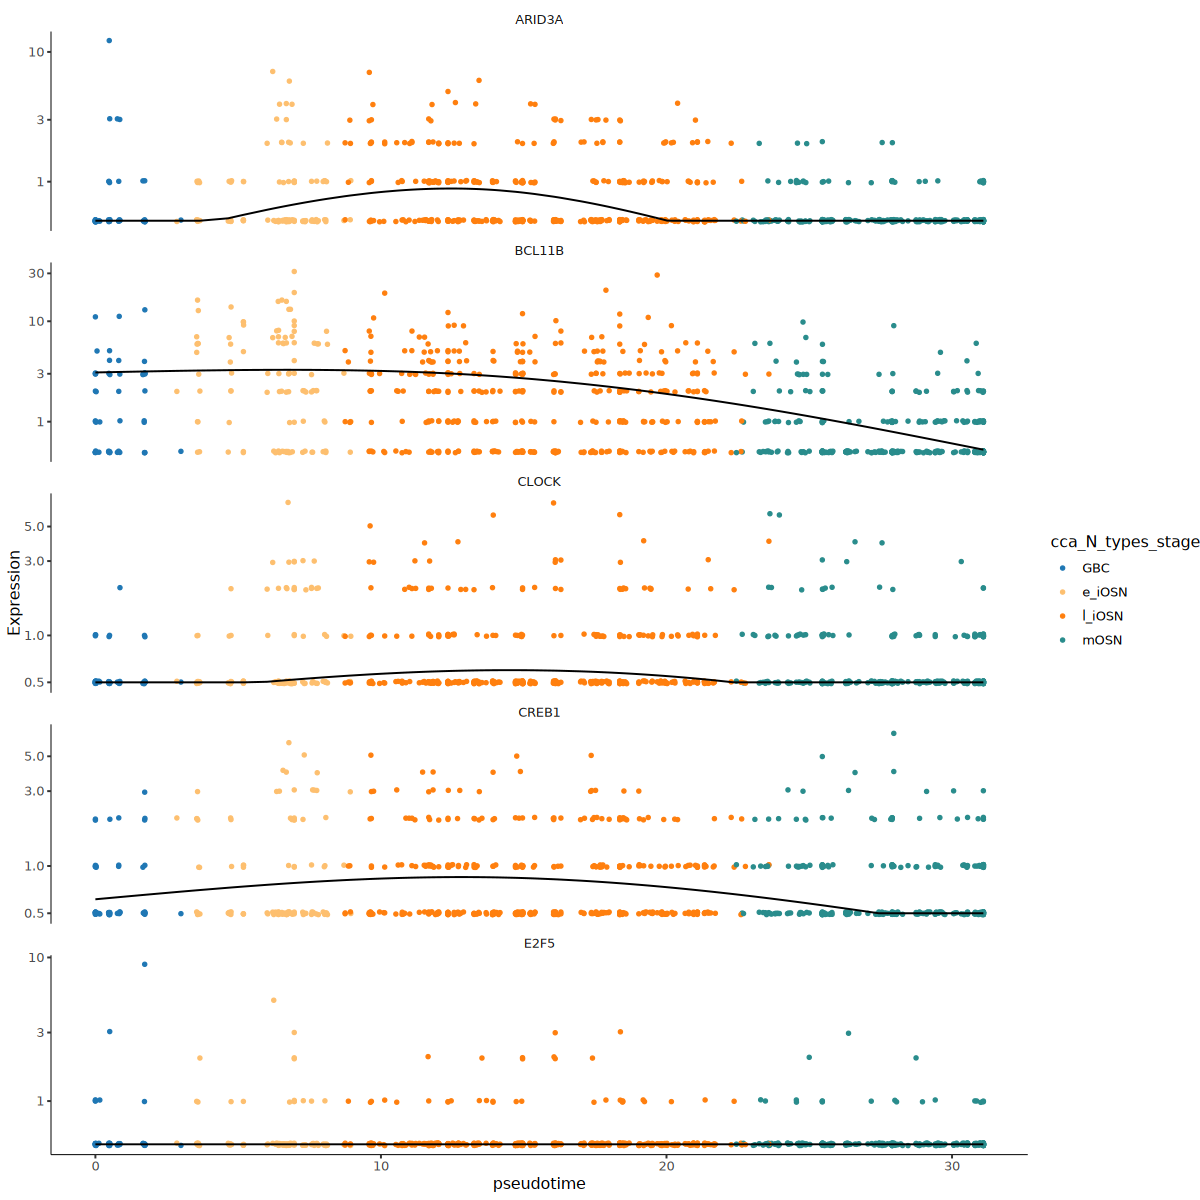

In [18]:

#[1] "ARID3A"   "BCL11B"   "CLOCK"    "CREB1"    "E2F5"     "ELK3"     "EP300"    "FOS"      "FOXJ3"    "GTF2IRD1" "MAFG"     "MBD2"    
#[13] "MYB"      "OTX1"     "PITX1"    "POU2F1"   "SMAD5"    "SP4"      "TFDP2"    "UBE2K"    "WRNIP1"   "YY2"      "ZBTB44"  


# monocle3::plot_genes_in_pseudotime(int_N[c('CUX2','RORB','THEMIS','TLE4','ID2','SST','AQP4','PLP1','PDGFRA'),] ,
#                                    label_by_short_name=F,
#                                    color_cells_by='cca_N_types_stage',
#                                    min_expr=0.5)+
# scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))

monocle3::plot_genes_in_pseudotime(int_N[c("ARID3A"  , "BCL11B" ,  "CLOCK" ,   "CREB1"  ,  "E2F5"   ),] ,
                                   label_by_short_name=F,
                                   color_cells_by='cca_N_types_stage',
                                   min_expr=0.5)+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))


pdf 
  2

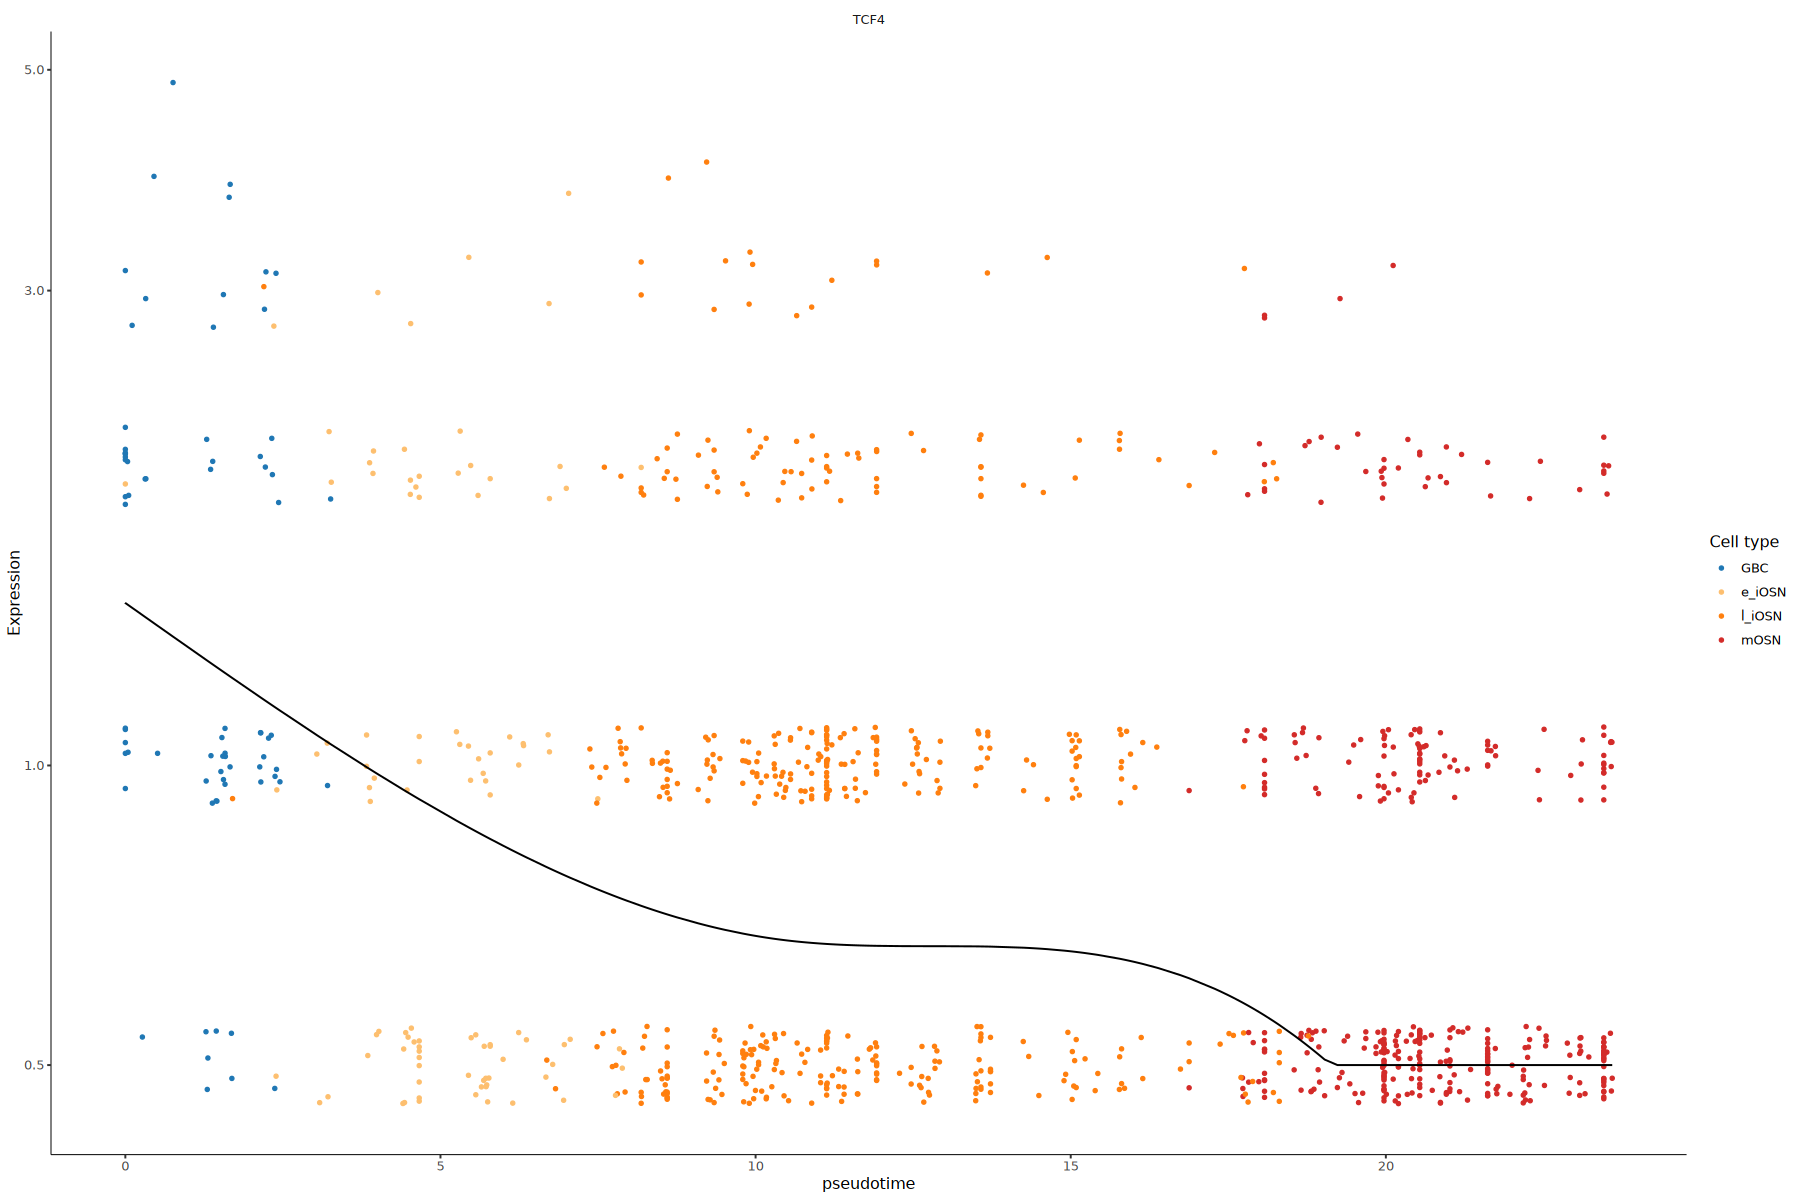

In [131]:
options(repr.plot.width = 18, repr.plot.height = 12, repr.plot.res = 100)
monocle3::plot_genes_in_pseudotime(int_N[c('TCF4'),] ,
                                   label_by_short_name=F,
                                   color_cells_by='cca_N_types_stage',
                                   min_expr=0.5)+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),
                   breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+labs(color = "Cell type")

dev.print(pdf, file='./figures/NC/tcf4_exp.pdf',height=3.5,width=4)

pdf 
  2

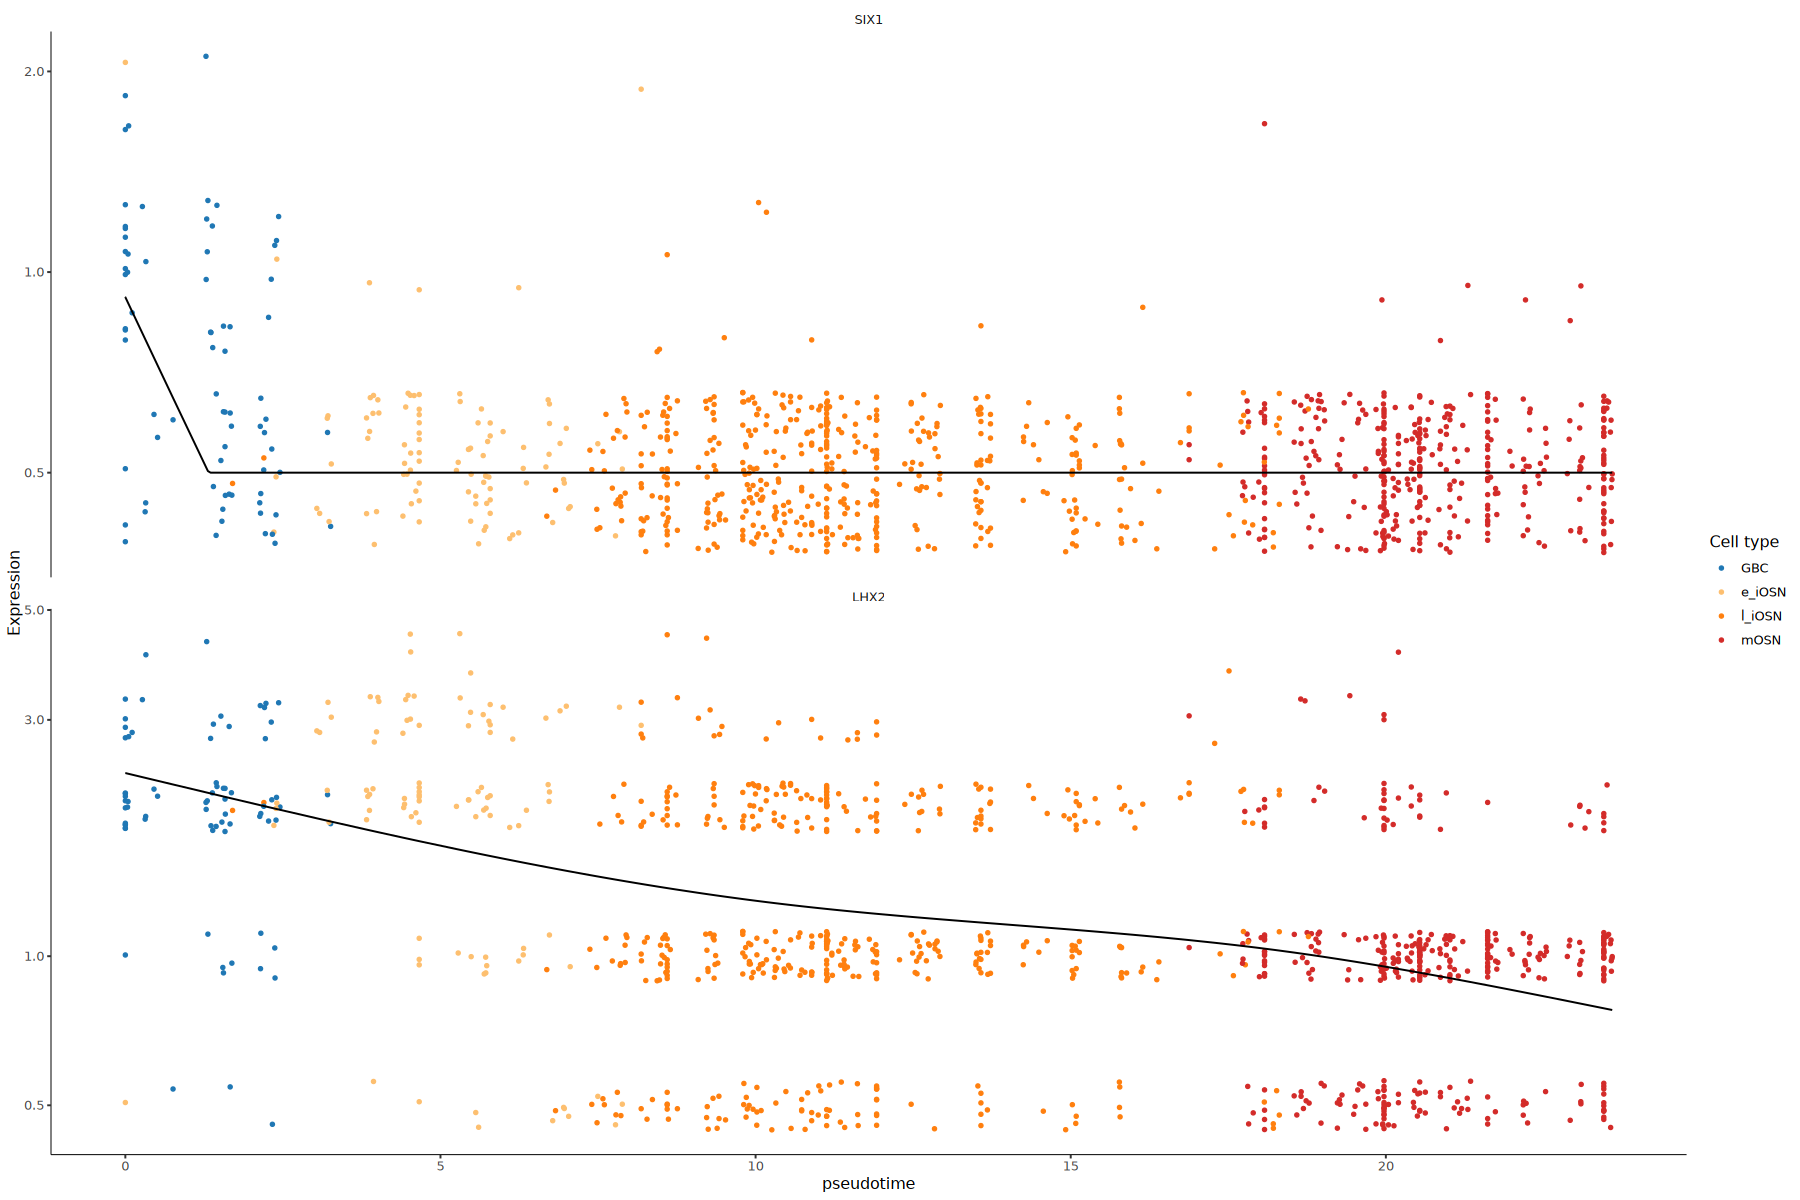

In [223]:
options(repr.plot.width = 18, repr.plot.height = 12, repr.plot.res = 100)
monocle3::plot_genes_in_pseudotime(int_N[c('SIX1','LHX2'),] ,
                                   label_by_short_name=F,
                                   color_cells_by='cca_N_types_stage',
                                   min_expr=0.5)+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),
                   breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+labs(color = "Cell type")

dev.print(pdf, file='./figures/NC/SIX1_LHX2_exp.pdf',height=5,width=4.5)

pdf 
  2

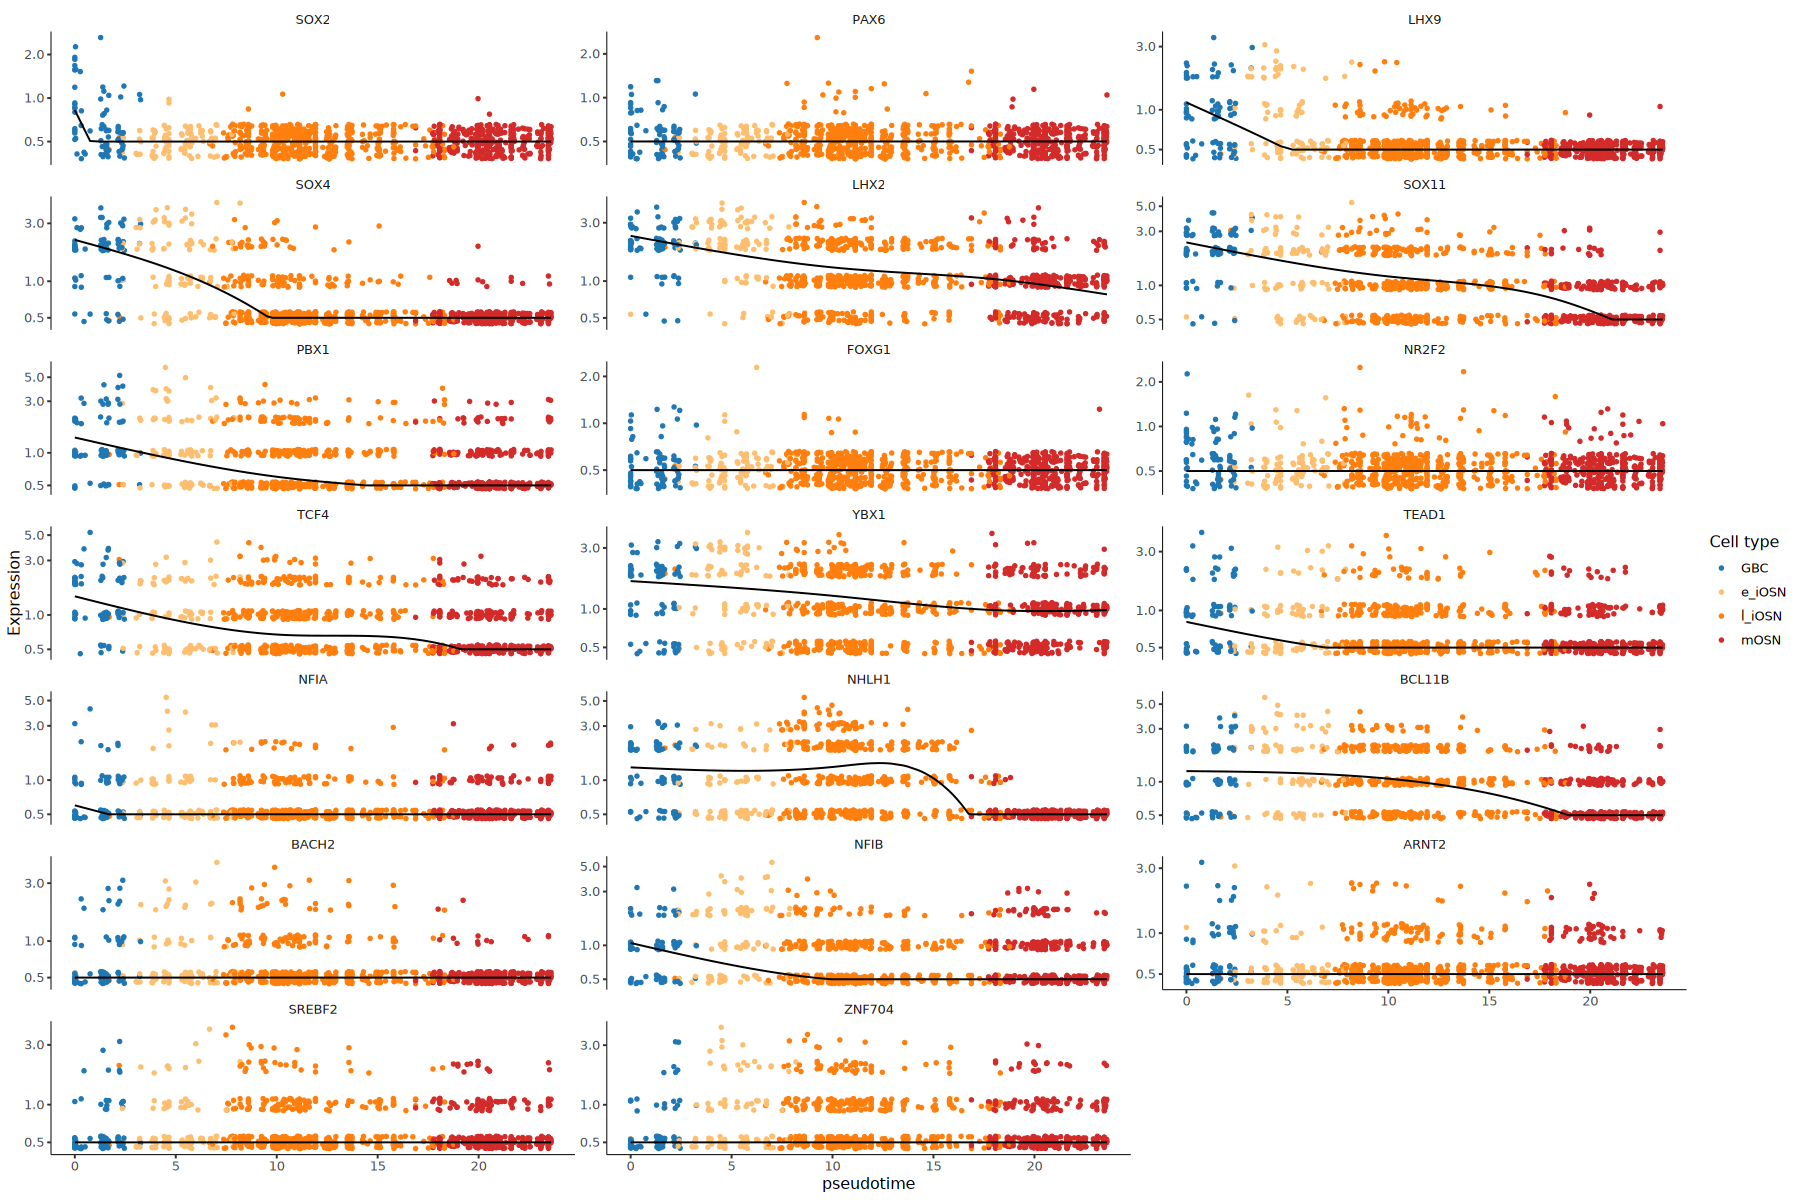

In [133]:
options(repr.plot.width = 18, repr.plot.height = 12, repr.plot.res = 100)
monocle3::plot_genes_in_pseudotime(int_N[c('SOX2','PAX6','LHX9','SOX4','LHX2', 'SOX11','PBX1','FOXG1','NR2F2','TCF4',
           #'ZNF85','HMGA2''POU6F2',
           'YBX1' ,'TEAD1','NFIA','NHLH1','BCL11B','BACH2','NFIB','ARNT2','SREBF2','ZNF704'),] ,
                                   label_by_short_name=F, ncol = 3,
                                   color_cells_by='cca_N_types_stage',
                                   min_expr=0.5)+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),
                   breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+labs(color = "Cell type")

dev.print(pdf, file='./figures/NC/PAX6_exp.pdf',height=6,width=7)

pdf 
  2

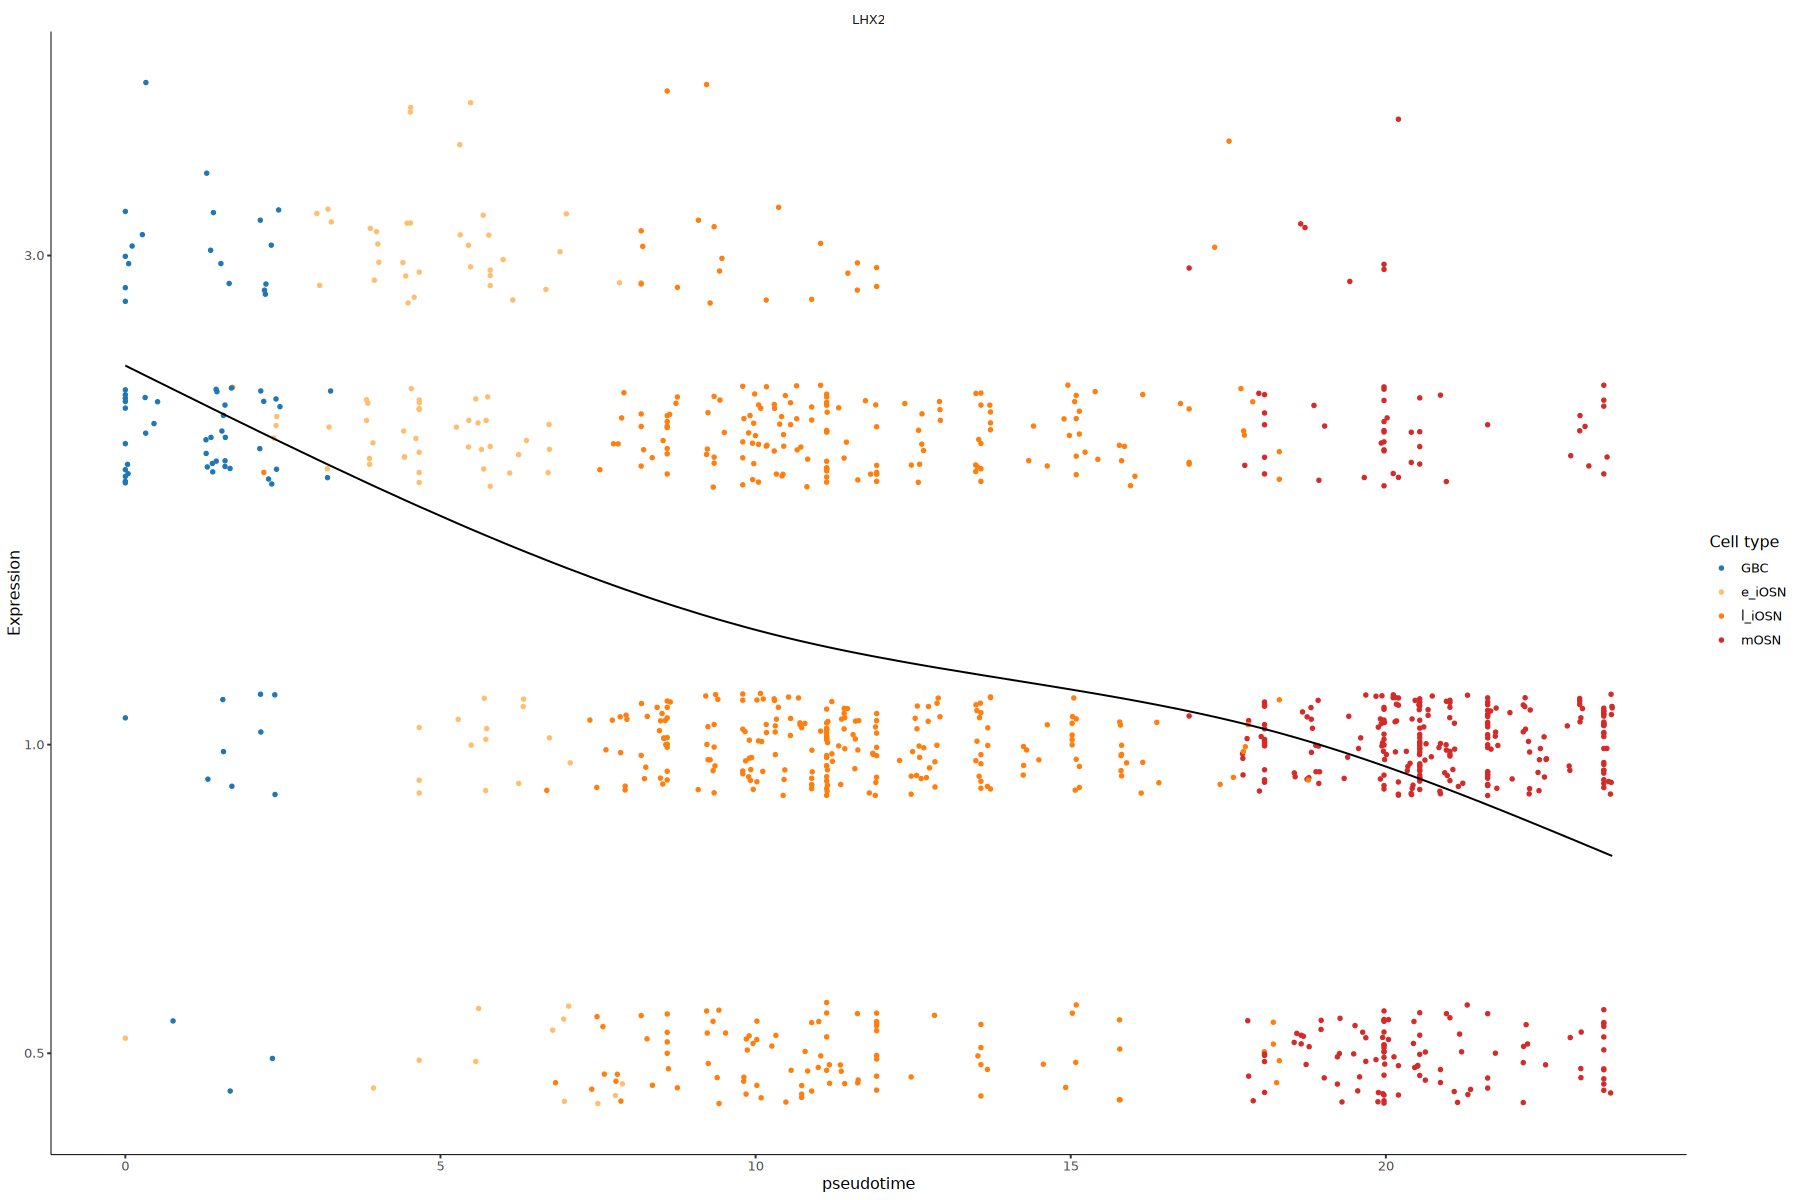

In [123]:
options(repr.plot.width = 18, repr.plot.height = 12, repr.plot.res = 100)
monocle3::plot_genes_in_pseudotime(int_N[c('LHX2'),] ,
                                   label_by_short_name=F,
                                   color_cells_by='cca_N_types_stage',
                                   min_expr=0.5)+
scale_color_manual(values =  c('#1f77b4','#FDBF6F','#ff7f0e',"#D32B29"),
                   breaks = c('GBC','e_iOSN','l_iOSN','mOSN'))+labs(color = "Cell type")

dev.print(pdf, file='./figures/NC/LHX2_exp.pdf',height=3.5,width=4)